Environment Setup

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import matplotlib.patches as mpatches
import seaborn as sns
from scipy import stats
import warnings
import os

warnings.filterwarnings('ignore')

OUTPUT_DIR = 'figures'
os.makedirs(OUTPUT_DIR, exist_ok=True)

PALETTE_PRIMARY   = ['#4361EE', '#3A0CA3', '#7209B7', '#F72585', '#4CC9F0']
PALETTE_DIVERGING = sns.color_palette('coolwarm', as_cmap=True)
PALETTE_SEQUENTIAL= sns.color_palette('Blues_r', as_cmap=True)
PALETTE_QUAL      = sns.color_palette('tab10')

plt.rcParams.update({
    'figure.facecolor': '#0F1117',
    'axes.facecolor'  : '#1A1D27',
    'axes.edgecolor'  : '#2E3250',
    'axes.labelcolor' : '#C8CBD8',
    'axes.titlecolor' : '#FFFFFF',
    'axes.titlesize'  : 14,
    'axes.labelsize'  : 11,
    'xtick.color'     : '#8B8FA8',
    'ytick.color'     : '#8B8FA8',
    'xtick.labelsize' : 9,
    'ytick.labelsize' : 9,
    'text.color'      : '#C8CBD8',
    'grid.color'      : '#2E3250',
    'grid.linestyle'  : '--',
    'grid.alpha'      : 0.5,
    'legend.facecolor': '#1A1D27',
    'legend.edgecolor': '#2E3250',
    'legend.fontsize' : 9,
    'font.family'     : 'DejaVu Sans',
    'figure.dpi'      : 130,
})

def save_fig(filename, tight=True):
    path = os.path.join(OUTPUT_DIR, filename)
    if tight:
        plt.tight_layout()
    plt.savefig(path, dpi=150, bbox_inches='tight', facecolor=plt.rcParams['figure.facecolor'])
    print(f'Figure saved → {path}')

print('Environment ready')

Environment ready


1. Data Loading & First Look

In [3]:
df = pd.read_csv("D:\\DA_PROJECTS\\AI Impact on JOB\\DATASET\\ai_jobs_salaries_clean.csv")
print(f'Shape: {df.shape[0]:,} rows × {df.shape[1]} columns')
print()
print('Column dtypes:')
print(df.dtypes)

Shape: 71,913 rows × 17 columns

Column dtypes:
work_year                  int64
experience_level          object
employment_type           object
job_title                 object
salary                     int64
salary_currency           object
salary_in_usd              int64
employee_residence        object
remote_ratio               int64
company_location          object
company_size              object
experience_level_label    object
employment_type_label     object
work_mode                 object
salary_outlier_flag         bool
role_family               object
isco_group_hint           object
dtype: object


In [4]:
df.head(10)

,work_year,experience_level,employment_type,job_title,salary,salary_currency,salary_in_usd,employee_residence,remote_ratio,company_location,company_size,experience_level_label,employment_type_label,work_mode,salary_outlier_flag,role_family,isco_group_hint
0,2025,EX,FT,Head of Data,348516,USD,348516,US,0,US,M,Executive-level,Full-time,On-site,True,Analytics Manager,Information and communications technology serv...
1,2025,EX,FT,Head of Data,232344,USD,232344,US,0,US,M,Executive-level,Full-time,On-site,False,Analytics Manager,Information and communications technology serv...
2,2025,SE,FT,Data Scientist,145400,USD,145400,US,0,US,M,Senior-level,Full-time,On-site,False,Data Scientist,"Mathematicians, actuaries and statisticians"
3,2025,SE,FT,Data Scientist,81600,USD,81600,US,0,US,M,Senior-level,Full-time,On-site,False,Data Scientist,"Mathematicians, actuaries and statisticians"
4,2025,MI,FT,Engineer,160000,USD,160000,US,100,US,M,Mid-level,Full-time,Remote,False,Other / Unclassified,NaN
5,2025,MI,FT,Engineer,140000,USD,140000,US,100,US,M,Mid-level,Full-time,Remote,False,Other / Unclassified,NaN
6,2025,SE,FT,AI Product Lead,175000,USD,175000,US,100,US,M,Senior-level,Full-time,Remote,False,Other / Unclassified,NaN
7,2025,SE,FT,AI Product Lead,152900,USD,152900,US,100,US,M,Senior-level,Full-time,Remote,False,Other / Unclassified,NaN
8,2025,SE,FT,AI Engineer,97900,USD,97900,US,100,US,M,Senior-level,Full-time,Remote,False,AI Engineer,Software and applications developers
9,2025,SE,FT,AI Engineer,89900,USD,89900,US,100,US,M,Senior-level,Full-time,Remote,False,AI Engineer,Software and applications developers


2. Data Quality Assessment

In [5]:
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)
quality_df = pd.DataFrame({'Missing Count': missing, 'Missing %': missing_pct, 'Dtype': df.dtypes})
quality_df = quality_df[quality_df['Missing Count'] >= 0].sort_values('Missing Count', ascending=False)
print('=== Missing Value Report ===')
print(quality_df.to_string())
print(f'\nDuplicate rows: {df.duplicated().sum():,}')

=== Missing Value Report ===
                        Missing Count  Missing %   Dtype
isco_group_hint                 40540      56.37  object
work_year                           0       0.00   int64
experience_level                    0       0.00  object
job_title                           0       0.00  object
employment_type                     0       0.00  object
salary_currency                     0       0.00  object
salary_in_usd                       0       0.00   int64
employee_residence                  0       0.00  object
salary                              0       0.00   int64
remote_ratio                        0       0.00   int64
company_location                    0       0.00  object
experience_level_label              0       0.00  object
company_size                        0       0.00  object
employment_type_label               0       0.00  object
work_mode                           0       0.00  object
salary_outlier_flag                 0       0.00    bool
ro

2. Data Quality Assessment

In [6]:
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)
quality_df = pd.DataFrame({'Missing Count': missing, 'Missing %': missing_pct, 'Dtype': df.dtypes})
quality_df = quality_df[quality_df['Missing Count'] >= 0].sort_values('Missing Count', ascending=False)
print('=== Missing Value Report ===')
print(quality_df.to_string())
print(f'\nDuplicate rows: {df.duplicated().sum():,}')

=== Missing Value Report ===
                        Missing Count  Missing %   Dtype
isco_group_hint                 40540      56.37  object
work_year                           0       0.00   int64
experience_level                    0       0.00  object
job_title                           0       0.00  object
employment_type                     0       0.00  object
salary_currency                     0       0.00  object
salary_in_usd                       0       0.00   int64
employee_residence                  0       0.00  object
salary                              0       0.00   int64
remote_ratio                        0       0.00   int64
company_location                    0       0.00  object
experience_level_label              0       0.00  object
company_size                        0       0.00  object
employment_type_label               0       0.00  object
work_mode                           0       0.00  object
salary_outlier_flag                 0       0.00    bool
ro

Figure saved → figures\01_missing_values.png


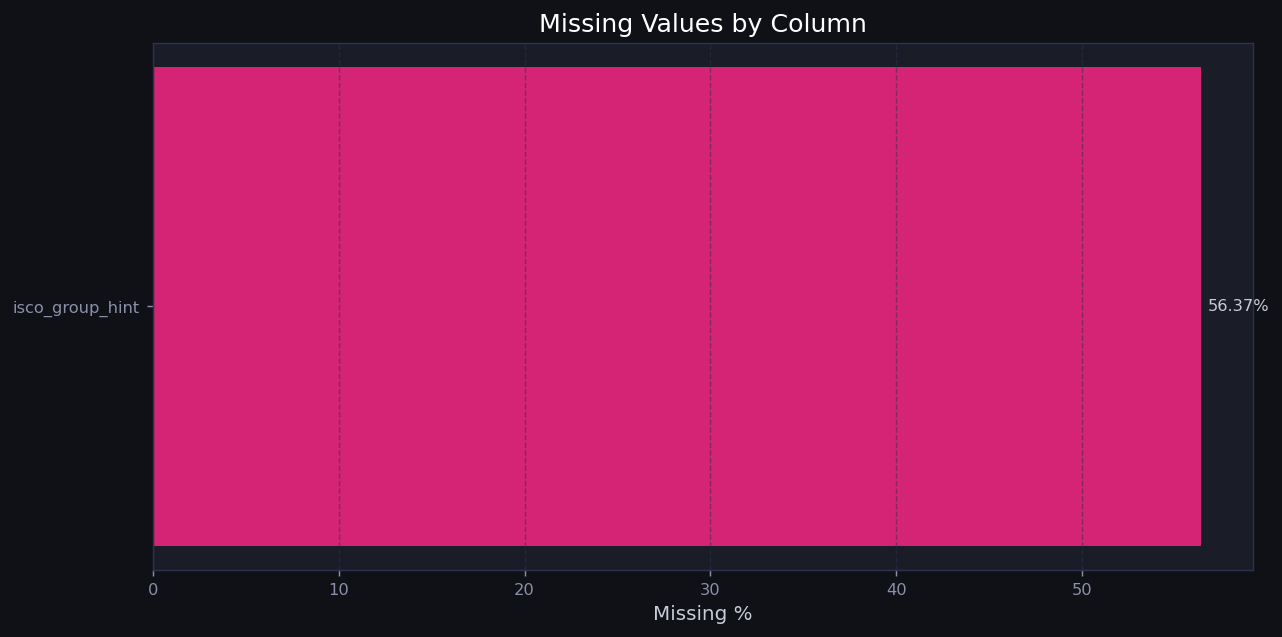

In [7]:
fig, ax = plt.subplots(figsize=(10, 5))

miss_plot = quality_df[quality_df['Missing Count'] > 0]
if not miss_plot.empty:
    bars = ax.barh(miss_plot.index, miss_plot['Missing %'], color='#F72585', alpha=0.85)
    ax.bar_label(bars, fmt='%.2f%%', padding=4, color='#C8CBD8', fontsize=9)
    ax.set_xlabel('Missing %')
    ax.set_title('Missing Values by Column')
    ax.grid(axis='x')
else:
    ax.text(0.5, 0.5, 'No Missing Values Detected', ha='center', va='center',
            fontsize=16, color='#4CC9F0', transform=ax.transAxes)
    ax.set_title('Missing Values Check')
    ax.axis('off')

save_fig('01_missing_values.png')
plt.show()

3. Descriptive Statistics

In [8]:
desc = df[['work_year', 'salary_in_usd', 'remote_ratio']].describe().T
desc['skewness'] = df[['work_year', 'salary_in_usd', 'remote_ratio']].skew()
desc['kurtosis'] = df[['work_year', 'salary_in_usd', 'remote_ratio']].kurt()
desc.round(2)


,count,mean,std,min,25%,50%,75%,max,skewness,kurtosis
work_year,71913.0,2024.43,0.72,2020.0,2024.0,2025.0,2025.0,2025.0,-1.45,3.20
salary_in_usd,71913.0,151161.25,77329.59,15000.0,96000.0,138750.0,190315.0,800000.0,1.48,5.12
remote_ratio,71913.0,24.57,42.92,0.0,0.0,0.0,0.0,100.0,1.18,-0.60


In [9]:
print('=== Categorical Column Value Counts ===')
cat_cols = ['experience_level_label', 'employment_type_label', 'work_mode', 'company_size', 'role_family']
for col in cat_cols:
    print(f'\n--- {col} ---')
    print(df[col].value_counts())

=== Categorical Column Value Counts ===

--- experience_level_label ---
experience_level_label
Senior-level       37702
Mid-level          23395
Entry-level         7975
Executive-level     2841
Name: count, dtype: int64

--- employment_type_label ---
employment_type_label
Full-time    71163
Contract       383
Part-time      351
Freelance       16
Name: count, dtype: int64

--- work_mode ---
work_mode
On-site    54081
Remote     17505
Hybrid       327
Name: count, dtype: int64

--- company_size ---
company_size
M    70110
L     1588
S      215
Name: count, dtype: int64

--- role_family ---
role_family
Other / Unclassified    40540
Data Analyst             8335
Data Engineer            7246
Data Scientist           7216
ML Engineer              3642
Research Scientist       2852
AI Engineer              1209
Analytics Manager         495
AI Architect              219
Computer Vision           140
NLP                        19
Name: count, dtype: int64


4. Univariate Analysis

4.1 Salary Distribution (USD)

Figure saved → figures\02_salary_distribution.png


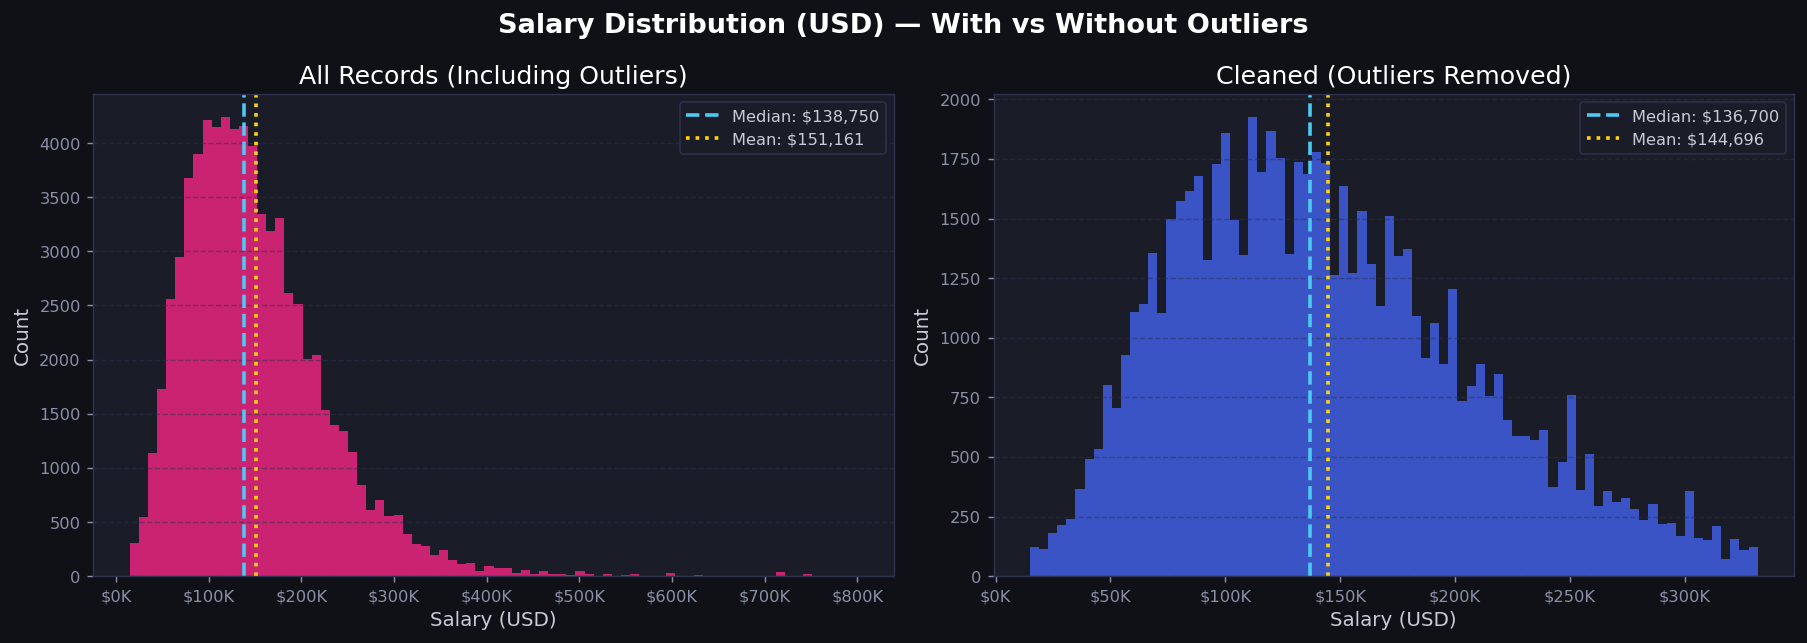

Outlier records: 1,754 (2.44%)
Clean dataset size: 70,159


In [10]:
df_clean = df[df['salary_outlier_flag'] == False].copy()
df_outlier = df[df['salary_outlier_flag'] == True].copy()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Salary Distribution (USD) — With vs Without Outliers', fontsize=15, fontweight='bold', color='white')

for ax, data, label, color in zip(
    axes,
    [df, df_clean],
    ['All Records (Including Outliers)', 'Cleaned (Outliers Removed)'],
    ['#F72585', '#4361EE']
):
    ax.hist(data['salary_in_usd'], bins=80, color=color, alpha=0.8, edgecolor='none')
    ax.axvline(data['salary_in_usd'].median(), color='#4CC9F0', lw=2, ls='--', label=f'Median: ${data["salary_in_usd"].median():,.0f}')
    ax.axvline(data['salary_in_usd'].mean(), color='#FFD60A', lw=2, ls=':', label=f'Mean: ${data["salary_in_usd"].mean():,.0f}')
    ax.set_title(label, color='white')
    ax.set_xlabel('Salary (USD)')
    ax.set_ylabel('Count')
    ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x/1000:.0f}K'))
    ax.legend()
    ax.grid(axis='y')

save_fig('02_salary_distribution.png')
plt.show()

print(f'Outlier records: {len(df_outlier):,} ({len(df_outlier)/len(df)*100:.2f}%)')
print(f'Clean dataset size: {len(df_clean):,}')

4.2 Year-wise Record Count

Figure saved → figures\03_records_per_year.png


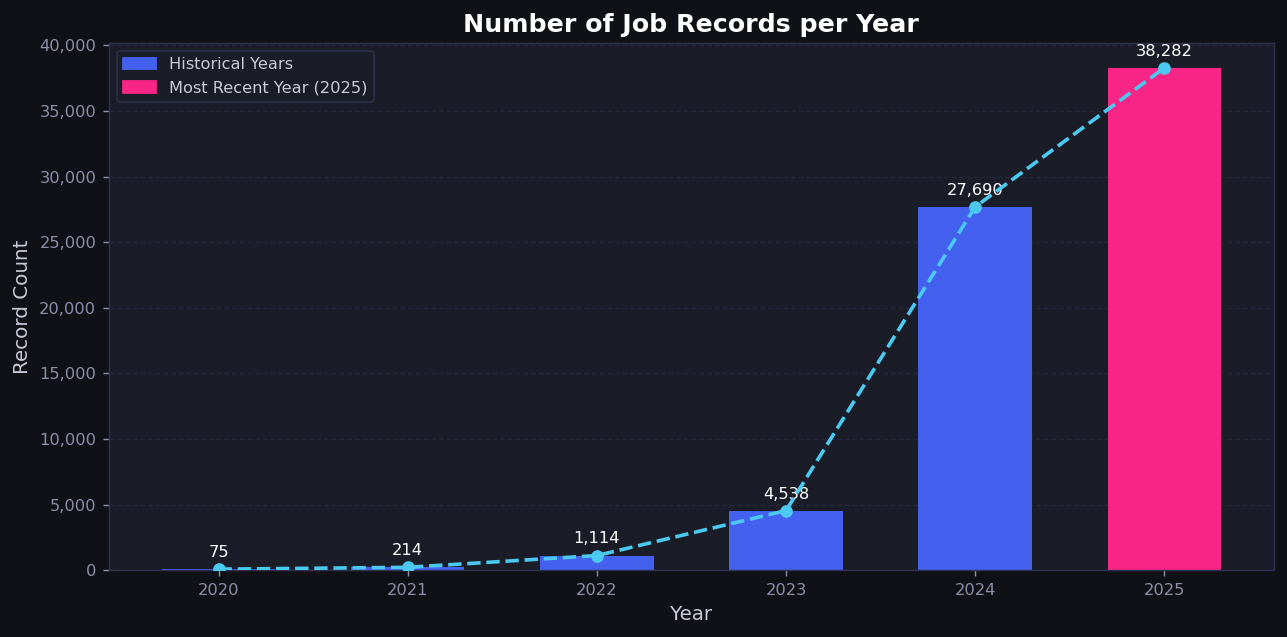

In [11]:
year_counts = df['work_year'].value_counts().sort_index()

fig, ax = plt.subplots(figsize=(10, 5))
colors_bar = ['#4361EE' if y < 2025 else '#F72585' for y in year_counts.index]
bars = ax.bar(year_counts.index, year_counts.values, color=colors_bar, width=0.6, zorder=2)
ax.bar_label(bars, fmt='{:,.0f}', padding=5, color='white', fontsize=9)
ax.plot(year_counts.index, year_counts.values, 'o--', color='#4CC9F0', lw=2, zorder=3)
ax.set_title('Number of Job Records per Year', fontsize=14, fontweight='bold')
ax.set_xlabel('Year')
ax.set_ylabel('Record Count')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:,.0f}'))
ax.grid(axis='y', zorder=1)

pink_patch = mpatches.Patch(color='#F72585', label='Most Recent Year (2025)')
blue_patch = mpatches.Patch(color='#4361EE', label='Historical Years')
ax.legend(handles=[blue_patch, pink_patch])

save_fig('03_records_per_year.png')
plt.show()

4.3 Categorical Feature Distributions

Figure saved → figures\04_categorical_distributions.png


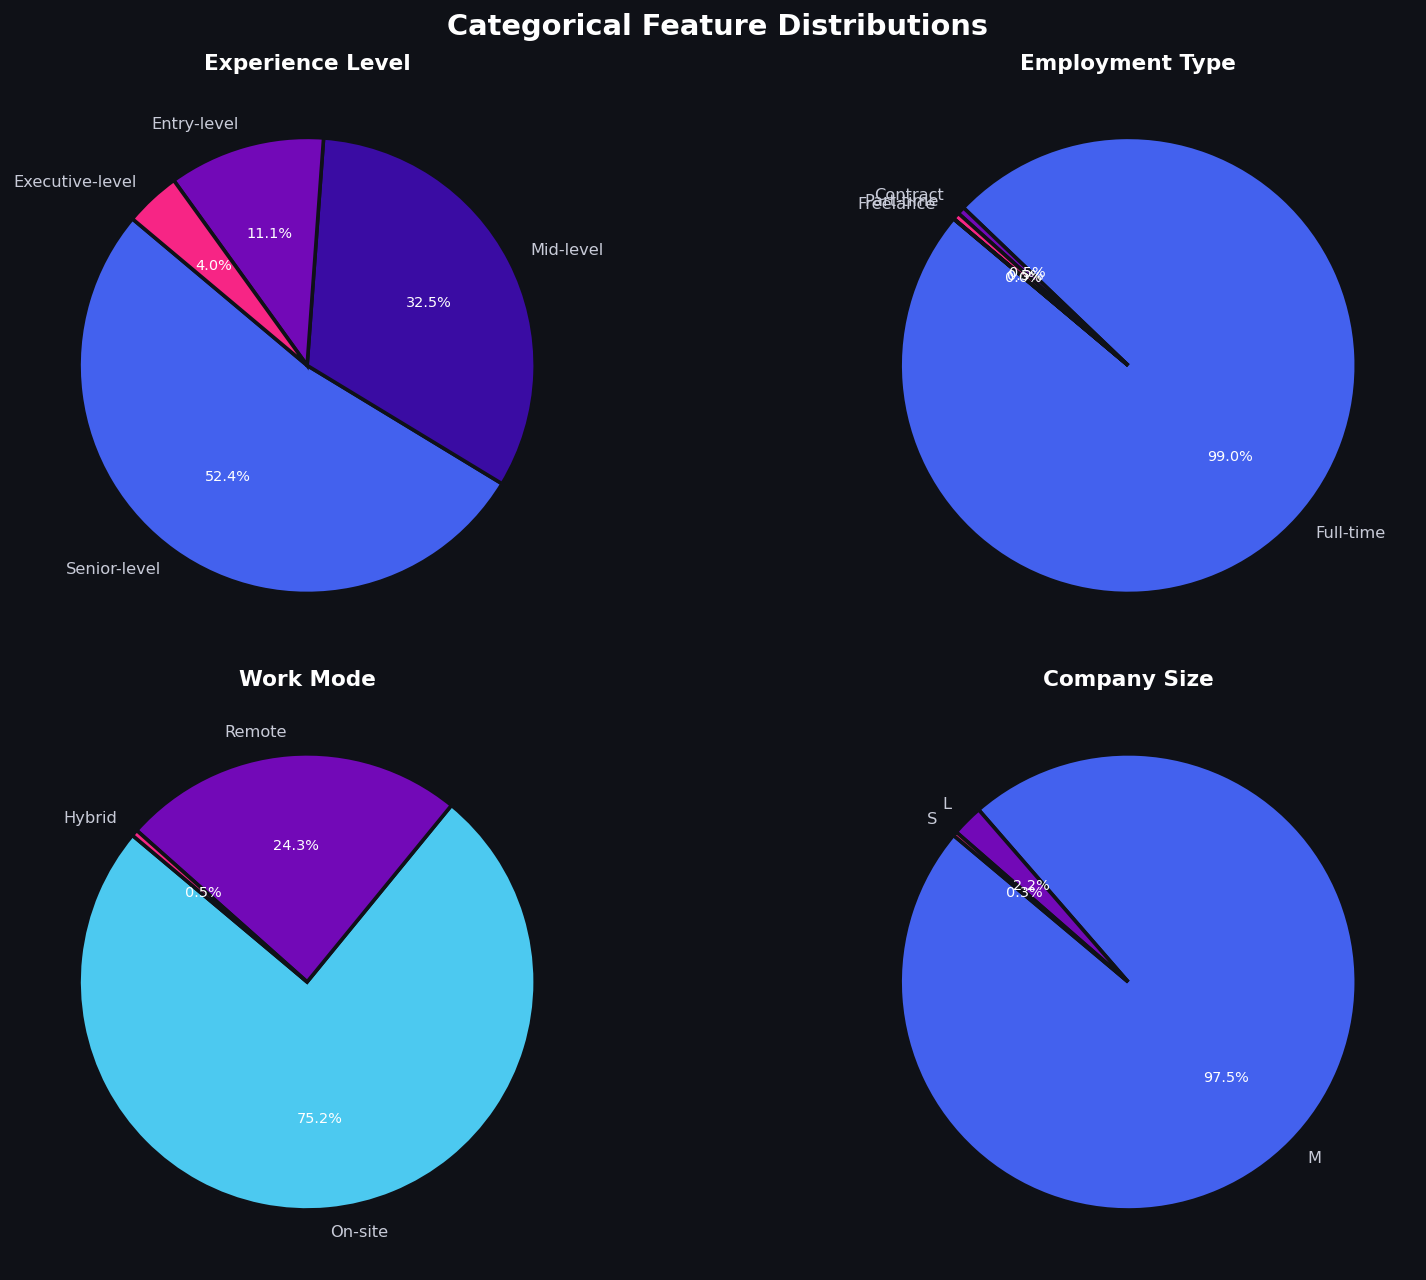

In [12]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Categorical Feature Distributions', fontsize=16, fontweight='bold', color='white')

cat_plot_info = [
    ('experience_level_label', 'Experience Level', PALETTE_PRIMARY),
    ('employment_type_label',  'Employment Type',  ['#4361EE','#7209B7','#F72585','#4CC9F0']),
    ('work_mode',              'Work Mode',         ['#4CC9F0','#7209B7','#F72585']),
    ('company_size',           'Company Size',      ['#4361EE','#7209B7','#F72585']),
]

for ax, (col, title, pal) in zip(axes.flat, cat_plot_info):
    vc = df[col].value_counts()
    wedges, texts, autotexts = ax.pie(
        vc.values, labels=vc.index, colors=pal,
        autopct='%1.1f%%', startangle=140,
        wedgeprops={'edgecolor': '#0F1117', 'linewidth': 2},
        textprops={'color': '#C8CBD8', 'fontsize': 9}
    )
    for at in autotexts:
        at.set_color('white')
        at.set_fontsize(8)
    ax.set_title(title, fontsize=12, fontweight='bold', color='white')

save_fig('04_categorical_distributions.png')
plt.show()

5. Temporal Analysis — AI Job Market Growth

5.1 Median Salary Trend Over Time

Figure saved → figures\05_salary_trend_over_time.png


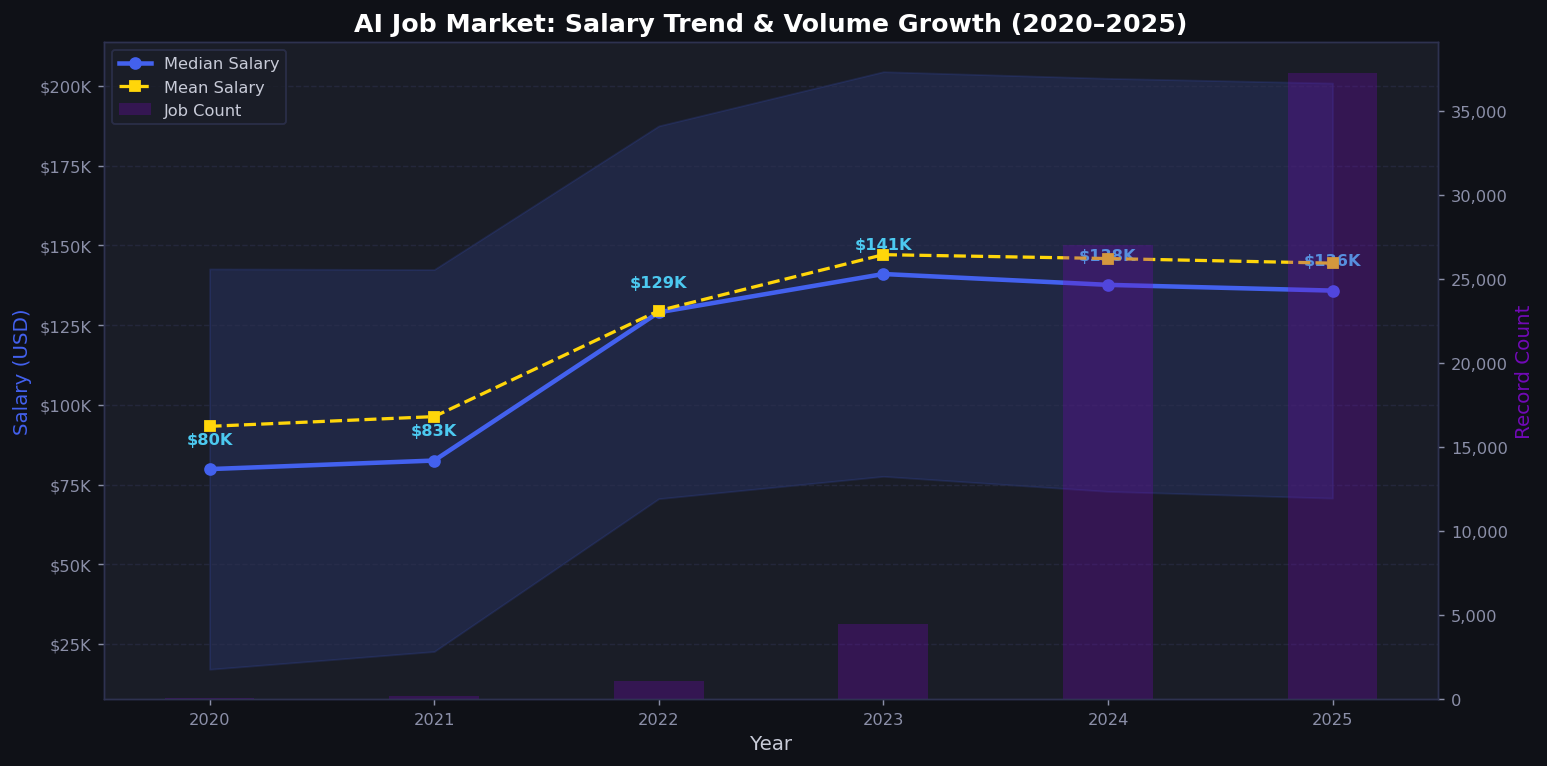

In [13]:
salary_trend = df_clean.groupby('work_year')['salary_in_usd'].agg(['median', 'mean', 'std', 'count']).reset_index()
salary_trend.columns = ['year', 'median', 'mean', 'std', 'count']

fig, ax1 = plt.subplots(figsize=(12, 6))
ax2 = ax1.twinx()

ax1.fill_between(salary_trend['year'],
                 salary_trend['median'] - salary_trend['std'],
                 salary_trend['median'] + salary_trend['std'],
                 alpha=0.15, color='#4361EE')
ax1.plot(salary_trend['year'], salary_trend['median'], 'o-', color='#4361EE', lw=2.5, label='Median Salary', zorder=5)
ax1.plot(salary_trend['year'], salary_trend['mean'],   's--', color='#FFD60A', lw=1.8, label='Mean Salary',   zorder=5)

for _, row in salary_trend.iterrows():
    ax1.annotate(f'${row["median"]/1000:.0f}K',
                 xy=(row['year'], row['median']),
                 xytext=(0, 14), textcoords='offset points',
                 ha='center', color='#4CC9F0', fontsize=9, fontweight='bold')

ax2.bar(salary_trend['year'], salary_trend['count'], color='#7209B7', alpha=0.3, width=0.4, label='Job Count')

ax1.set_title('AI Job Market: Salary Trend & Volume Growth (2020–2025)', fontsize=14, fontweight='bold')
ax1.set_xlabel('Year')
ax1.set_ylabel('Salary (USD)', color='#4361EE')
ax1.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x/1000:.0f}K'))
ax2.set_ylabel('Record Count', color='#7209B7')
ax2.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:,.0f}'))
ax1.grid(axis='y')

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper left')

save_fig('05_salary_trend_over_time.png')
plt.show()

5.2 Role Family Growth Over Time

Figure saved → figures\06_role_family_growth.png


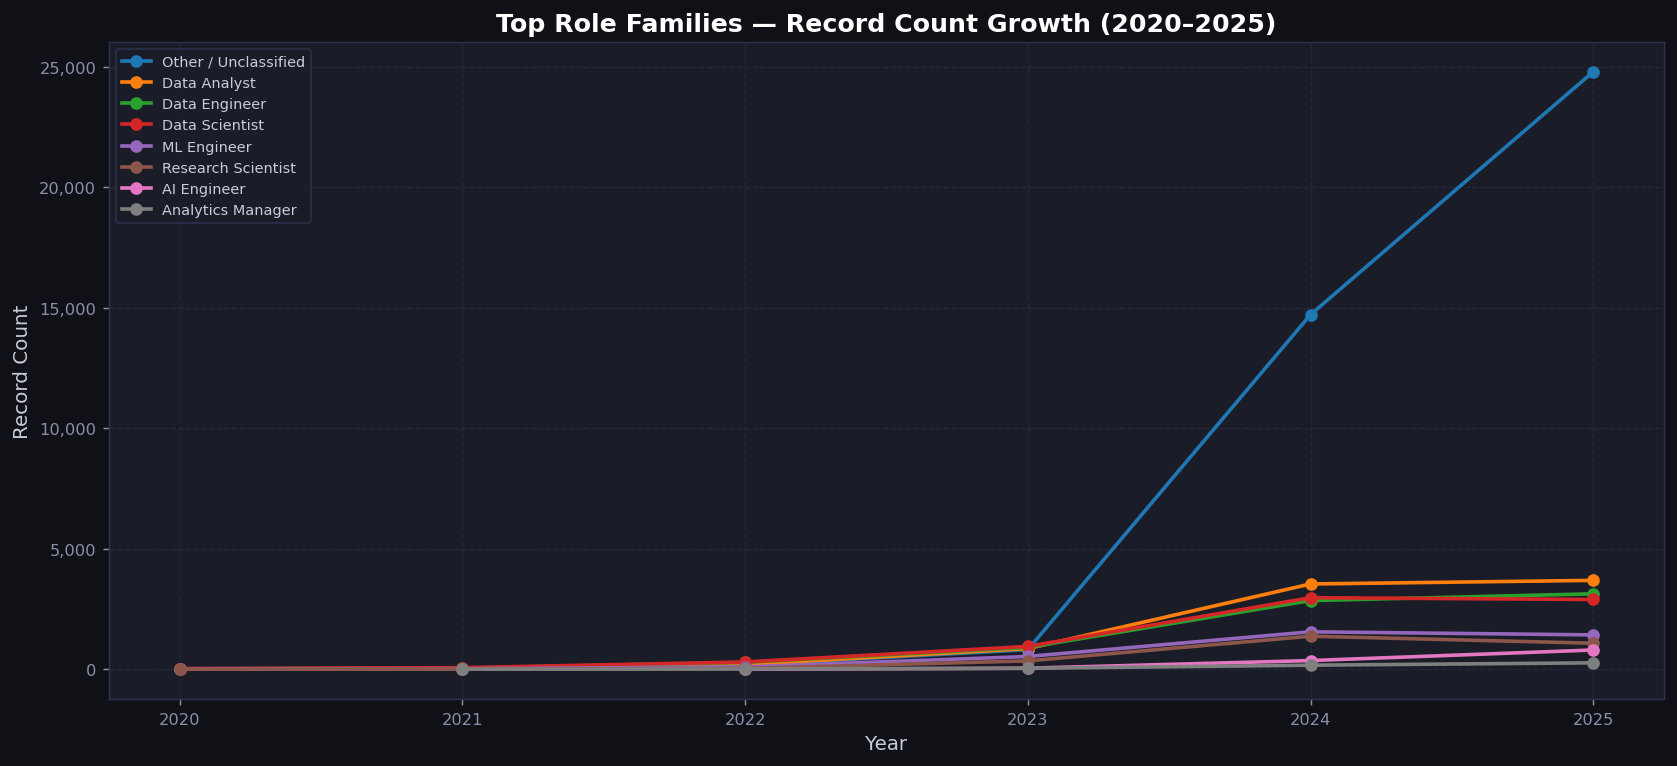

In [14]:
top_roles = df['role_family'].value_counts().head(8).index
role_year = (
    df[df['role_family'].isin(top_roles)]
    .groupby(['work_year', 'role_family'])
    .size()
    .reset_index(name='count')
)

fig, ax = plt.subplots(figsize=(13, 6))
pal = sns.color_palette('tab10', n_colors=len(top_roles))

for i, role in enumerate(top_roles):
    subset = role_year[role_year['role_family'] == role]
    ax.plot(subset['work_year'], subset['count'], 'o-', lw=2, color=pal[i], label=role)

ax.set_title('Top Role Families — Record Count Growth (2020–2025)', fontsize=14, fontweight='bold')
ax.set_xlabel('Year')
ax.set_ylabel('Record Count')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:,.0f}'))
ax.legend(loc='upper left', fontsize=8)
ax.grid()

save_fig('06_role_family_growth.png')
plt.show()

6. Salary Analysis by Key Dimensions

6.1 Salary by Experience Level

Figure saved → figures\07_salary_by_experience.png


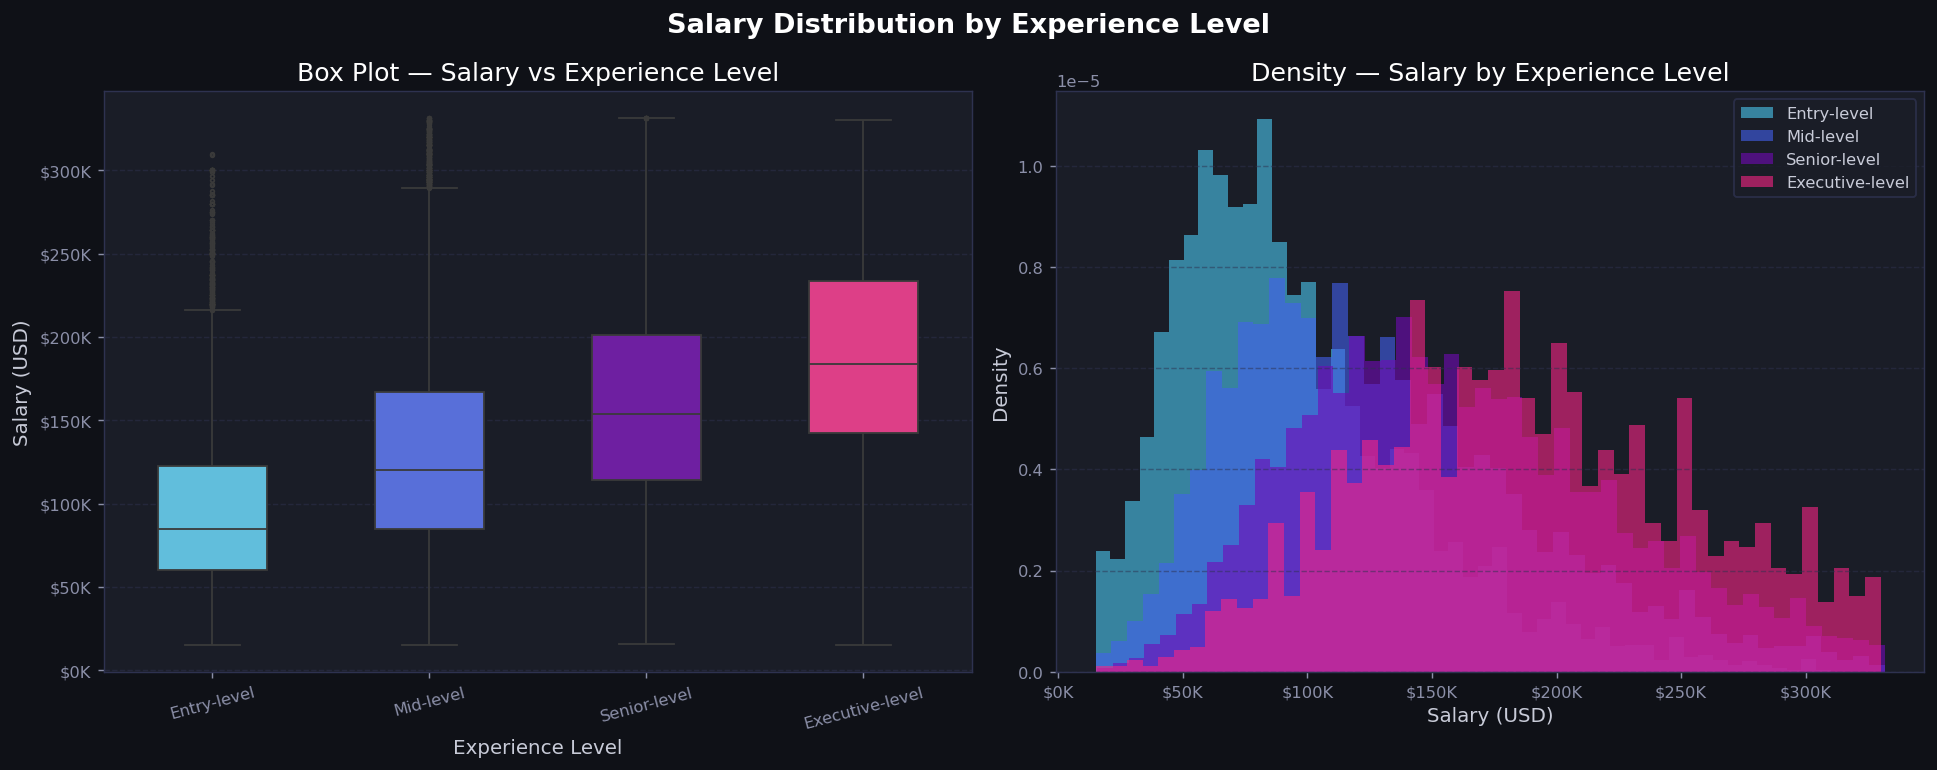

Median Salary by Experience Level:
                          median      mean  count
experience_level_label                           
Entry-level              85080.0   96019.0   7927
Mid-level               120000.0  130783.0  22971
Senior-level            153600.0  160838.0  36623
Executive-level         183900.0  188040.0   2638


In [15]:
exp_order = ['Entry-level', 'Mid-level', 'Senior-level', 'Executive-level']
exp_palette = {'Entry-level': '#4CC9F0', 'Mid-level': '#4361EE', 'Senior-level': '#7209B7', 'Executive-level': '#F72585'}

fig, axes = plt.subplots(1, 2, figsize=(15, 6))
fig.suptitle('Salary Distribution by Experience Level', fontsize=15, fontweight='bold', color='white')

sns.boxplot(
    data=df_clean, x='experience_level_label', y='salary_in_usd',
    order=exp_order, palette=exp_palette,
    width=0.5, fliersize=2, ax=axes[0]
)
axes[0].set_title('Box Plot — Salary vs Experience Level')
axes[0].set_xlabel('Experience Level')
axes[0].set_ylabel('Salary (USD)')
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x/1000:.0f}K'))
axes[0].tick_params(axis='x', rotation=15)
axes[0].grid(axis='y')

for level, color in exp_palette.items():
    subset = df_clean[df_clean['experience_level_label'] == level]['salary_in_usd']
    axes[1].hist(subset, bins=50, alpha=0.6, label=level, color=color, density=True)

axes[1].set_title('Density — Salary by Experience Level')
axes[1].set_xlabel('Salary (USD)')
axes[1].set_ylabel('Density')
axes[1].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x/1000:.0f}K'))
axes[1].legend()
axes[1].grid(axis='y')

save_fig('07_salary_by_experience.png')
plt.show()

print('Median Salary by Experience Level:')
print(df_clean.groupby('experience_level_label')['salary_in_usd'].agg(['median','mean','count']).reindex(exp_order).round(0))

6.2 Salary by Role Family


Figure saved → figures\08_salary_by_role_family.png


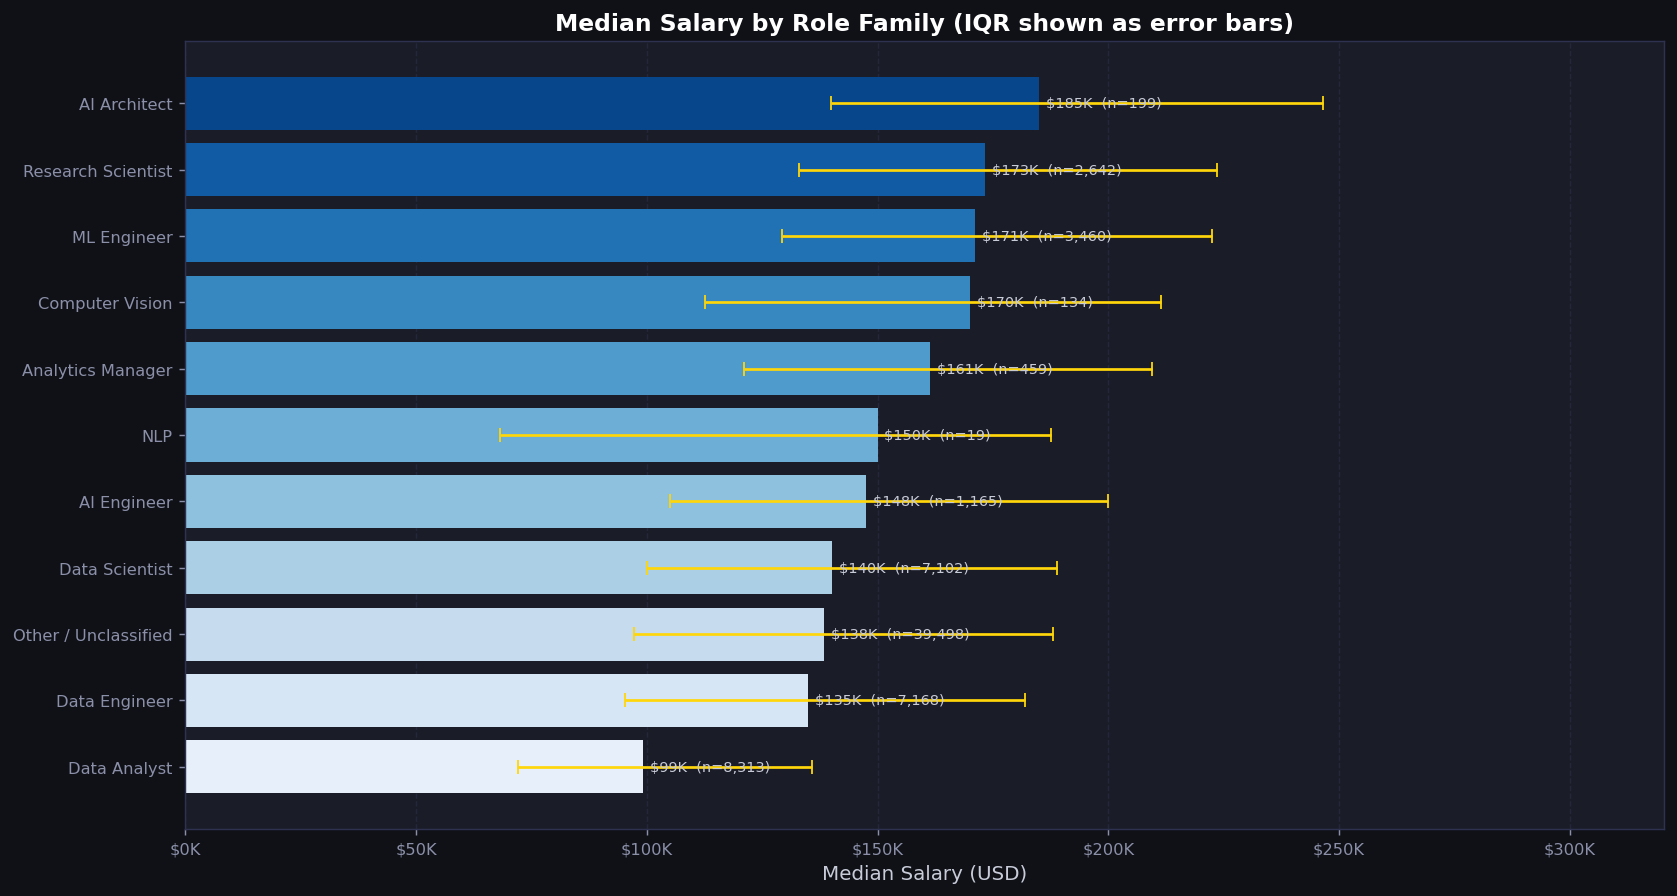

In [16]:
role_salary = (
    df_clean.groupby('role_family')['salary_in_usd']
    .agg(median='median', q25=lambda x: x.quantile(0.25), q75=lambda x: x.quantile(0.75), count='count')
    .sort_values('median', ascending=False)
    .reset_index()
)

fig, ax = plt.subplots(figsize=(13, 7))

colors = sns.color_palette('Blues_r', n_colors=len(role_salary))
bars = ax.barh(role_salary['role_family'], role_salary['median'], color=colors, zorder=2)

ax.errorbar(
    role_salary['median'], role_salary['role_family'],
    xerr=[role_salary['median'] - role_salary['q25'], role_salary['q75'] - role_salary['median']],
    fmt='none', color='#FFD60A', lw=1.5, capsize=4, zorder=3
)

for bar, (_, row) in zip(bars, role_salary.iterrows()):
    ax.text(bar.get_width() + 1500, bar.get_y() + bar.get_height()/2,
            f'${row["median"]/1000:.0f}K  (n={int(row["count"]):,})',
            va='center', fontsize=8, color='#C8CBD8')

ax.set_title('Median Salary by Role Family (IQR shown as error bars)', fontsize=13, fontweight='bold')
ax.set_xlabel('Median Salary (USD)')
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x/1000:.0f}K'))
ax.set_xlim(0, role_salary['q75'].max() * 1.3)
ax.grid(axis='x', zorder=1)
ax.invert_yaxis()

save_fig('08_salary_by_role_family.png')
plt.show()

6.3 Top 20 Highest-Paying Job Titles

Figure saved → figures\09_top20_job_titles.png


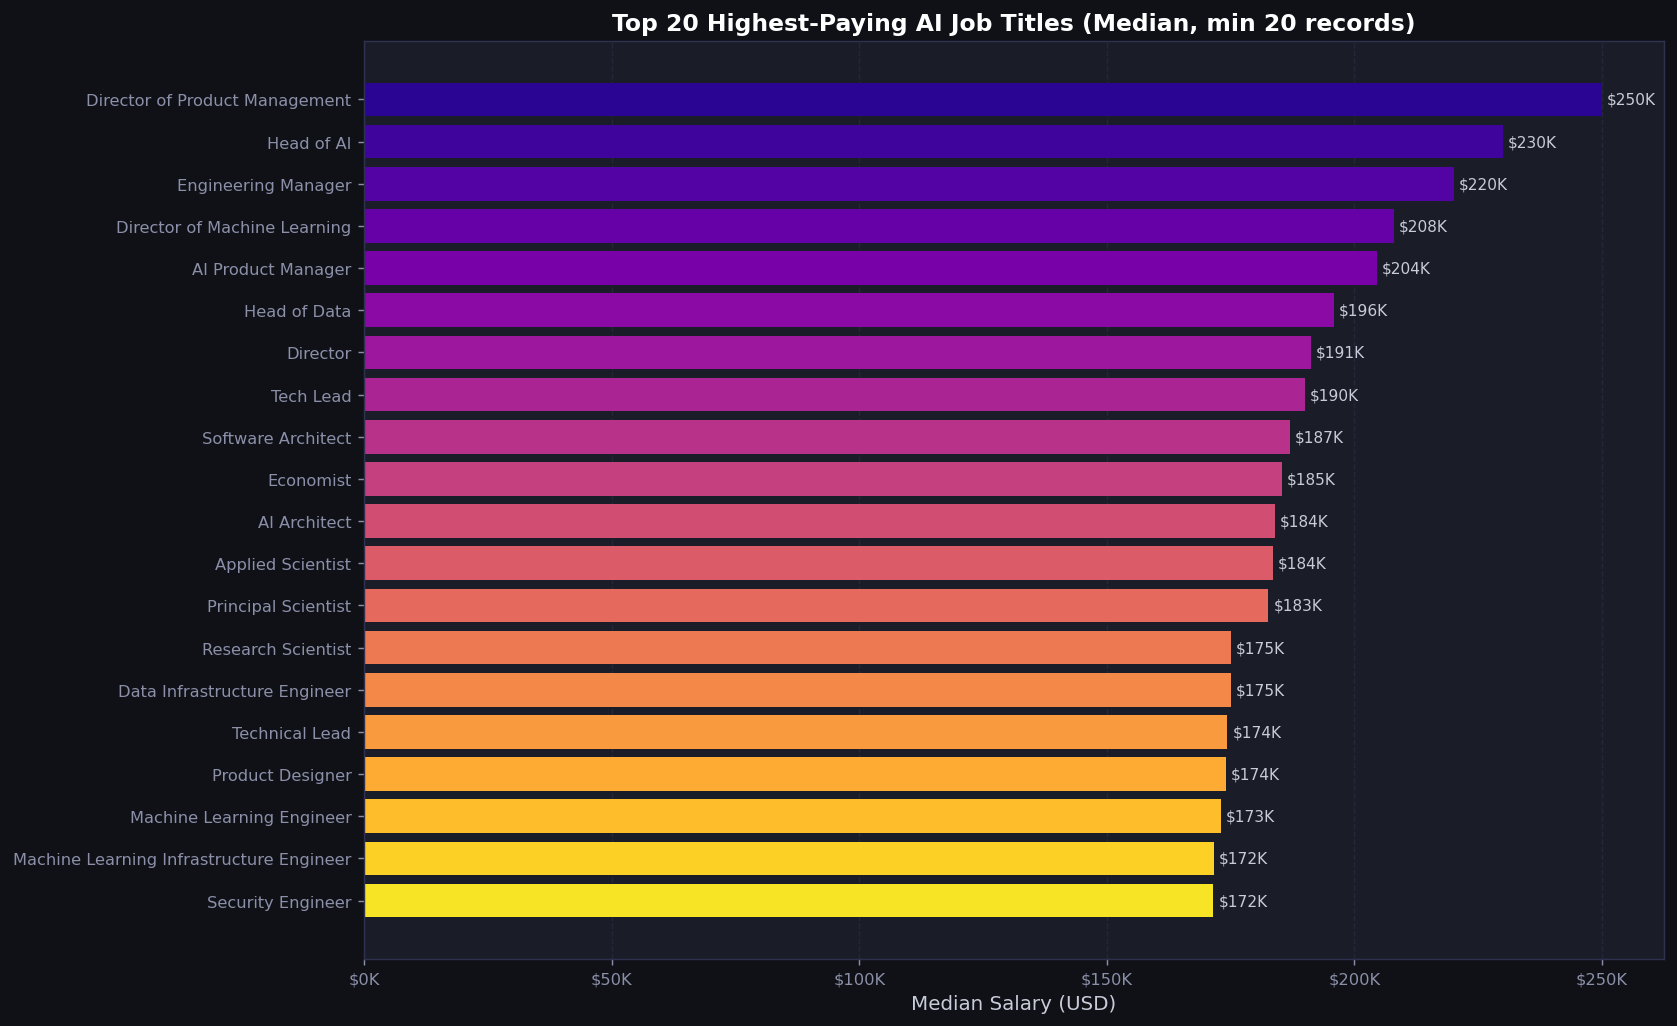

In [17]:
top_titles = (
    df_clean.groupby('job_title')['salary_in_usd']
    .agg(median='median', count='count')
    .query('count >= 20')
    .sort_values('median', ascending=False)
    .head(20)
    .reset_index()
)

fig, ax = plt.subplots(figsize=(13, 8))
color_grad = sns.color_palette('plasma', n_colors=len(top_titles))
bars = ax.barh(top_titles['job_title'], top_titles['median'], color=color_grad, zorder=2)

for bar, (_, row) in zip(bars, top_titles.iterrows()):
    ax.text(bar.get_width() + 1000, bar.get_y() + bar.get_height()/2,
            f'${row["median"]/1000:.0f}K', va='center', fontsize=8.5, color='#C8CBD8')

ax.set_title('Top 20 Highest-Paying AI Job Titles (Median, min 20 records)', fontsize=13, fontweight='bold')
ax.set_xlabel('Median Salary (USD)')
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x/1000:.0f}K'))
ax.grid(axis='x', zorder=1)
ax.invert_yaxis()

save_fig('09_top20_job_titles.png')
plt.show()

6.4 Salary by Work Mode (On-site vs Hybrid vs Remote)

Figure saved → figures\10_salary_by_work_mode.png


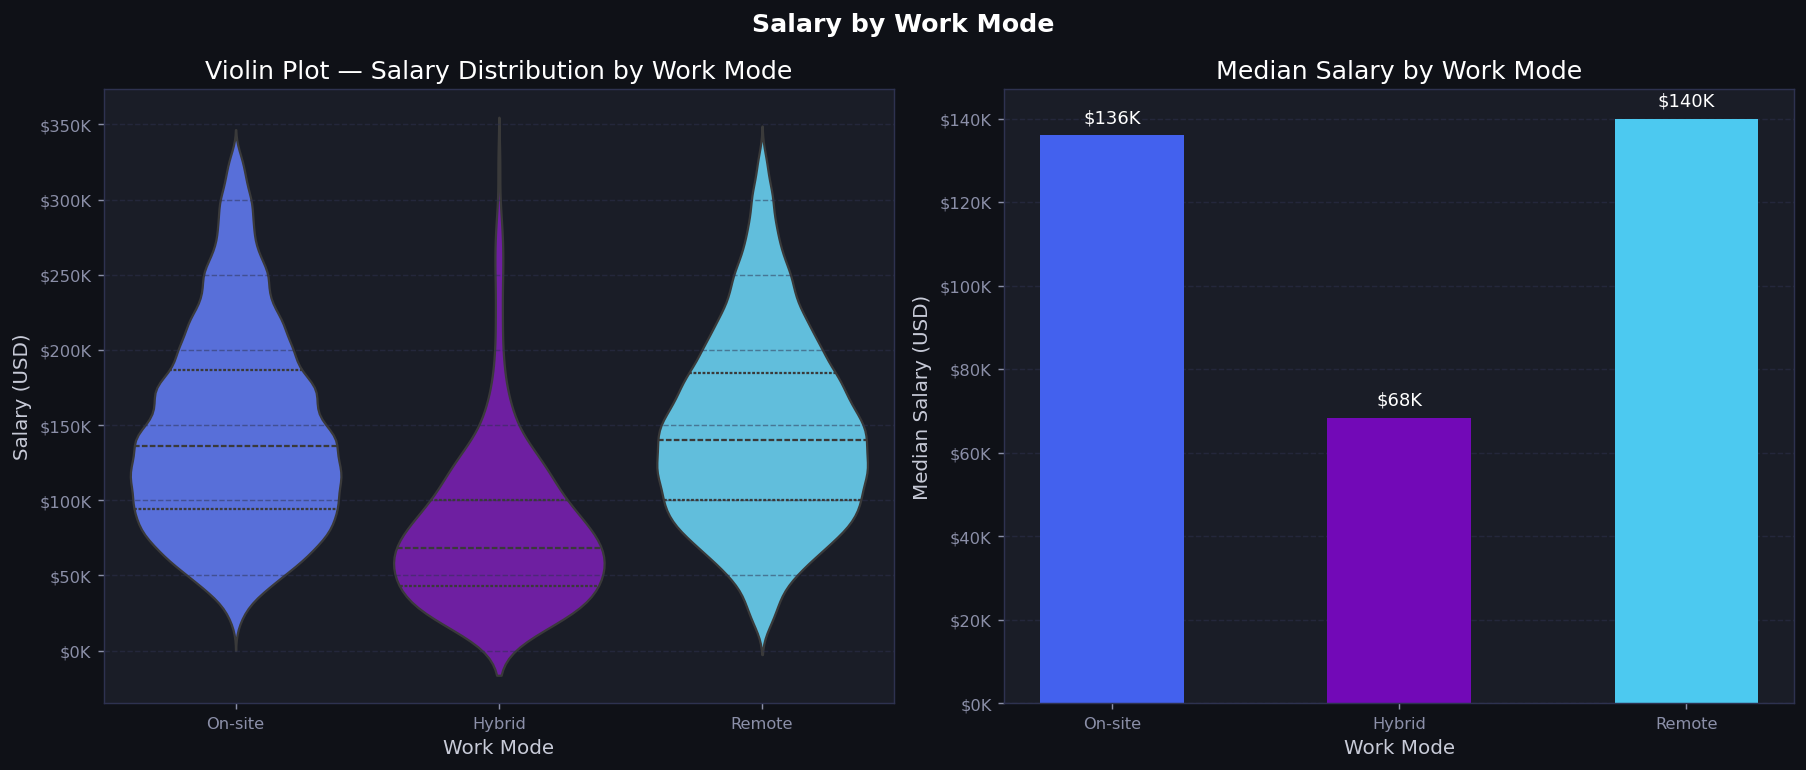

Median Salary by Work Mode:
             median      mean  count
work_mode                           
On-site    136000.0  144843.0  52570
Hybrid      68276.0   78841.0    324
Remote     140000.0  145486.0  17265


In [18]:
work_mode_order = ['On-site', 'Hybrid', 'Remote']
work_mode_palette = {'On-site': '#4361EE', 'Hybrid': '#7209B7', 'Remote': '#4CC9F0'}

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle('Salary by Work Mode', fontsize=14, fontweight='bold', color='white')

sns.violinplot(
    data=df_clean, x='work_mode', y='salary_in_usd',
    order=work_mode_order, palette=work_mode_palette,
    inner='quartile', ax=axes[0]
)
axes[0].set_title('Violin Plot — Salary Distribution by Work Mode')
axes[0].set_xlabel('Work Mode')
axes[0].set_ylabel('Salary (USD)')
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x/1000:.0f}K'))
axes[0].grid(axis='y')

wm_stats = df_clean.groupby('work_mode')['salary_in_usd'].median().reindex(work_mode_order)
bars = axes[1].bar(wm_stats.index, wm_stats.values,
                   color=[work_mode_palette[w] for w in wm_stats.index],
                   width=0.5, zorder=2)
axes[1].bar_label(bars, fmt=lambda x: f'${x/1000:.0f}K', padding=5, color='white', fontsize=10)
axes[1].set_title('Median Salary by Work Mode')
axes[1].set_xlabel('Work Mode')
axes[1].set_ylabel('Median Salary (USD)')
axes[1].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x/1000:.0f}K'))
axes[1].grid(axis='y', zorder=1)

save_fig('10_salary_by_work_mode.png')
plt.show()

print('Median Salary by Work Mode:')
print(df_clean.groupby('work_mode')['salary_in_usd'].agg(['median','mean','count']).reindex(work_mode_order).round(0))


6.5 Salary by Company Size

Figure saved → figures\11_salary_by_company_size.png


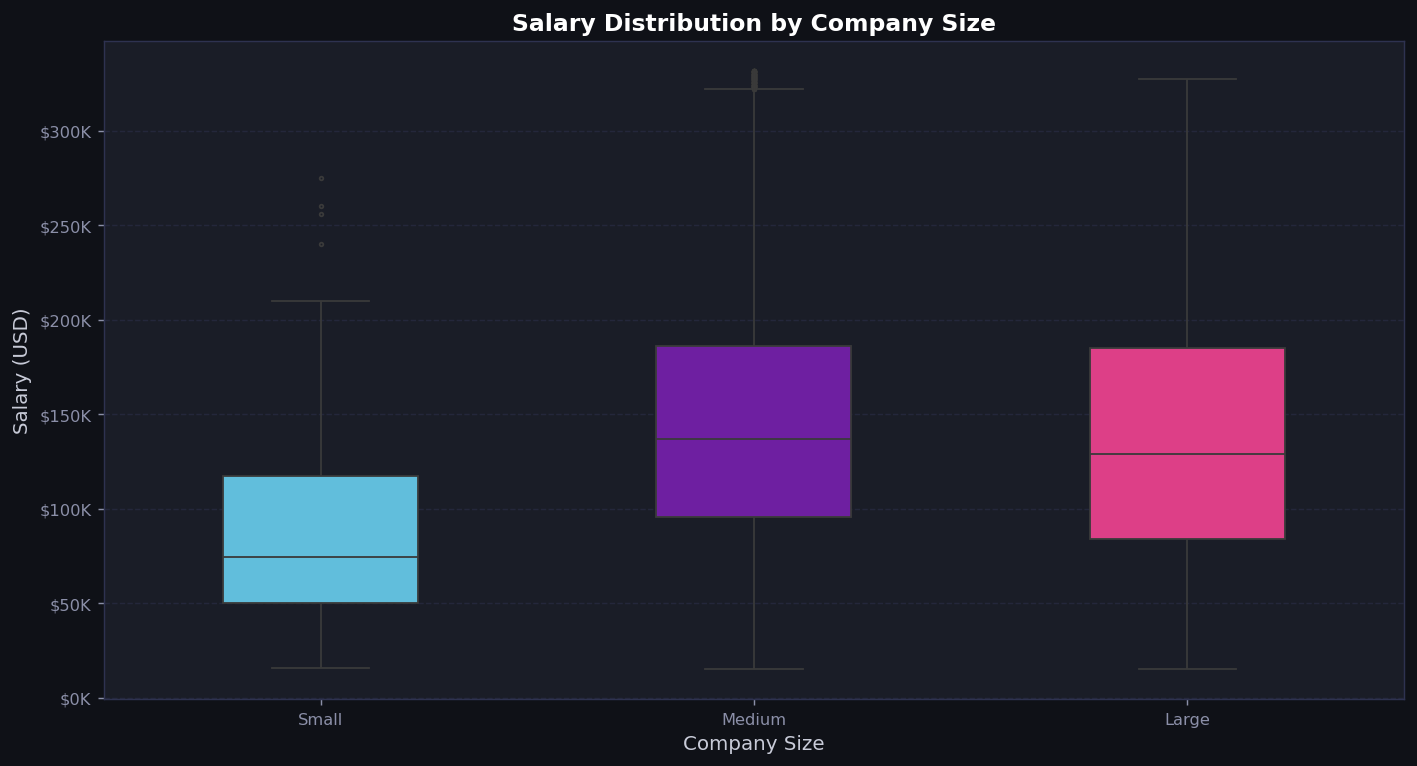

Median Salary by Company Size:
              median      mean  count
size_label                           
Small        74500.0   86431.0    214
Medium      137000.0  145097.0  68375
Large       128900.0  135202.0   1570


In [19]:
size_order   = ['S', 'M', 'L']
size_labels  = {'S': 'Small', 'M': 'Medium', 'L': 'Large'}
size_palette = {'S': '#4CC9F0', 'M': '#7209B7', 'L': '#F72585'}

df_size = df_clean.copy()
df_size['size_label'] = df_size['company_size'].map(size_labels)
size_label_order = ['Small', 'Medium', 'Large']

fig, ax = plt.subplots(figsize=(11, 6))
sns.boxplot(
    data=df_size, x='size_label', y='salary_in_usd',
    order=size_label_order,
    palette={'Small': '#4CC9F0', 'Medium': '#7209B7', 'Large': '#F72585'},
    width=0.45, fliersize=2, ax=ax
)
ax.set_title('Salary Distribution by Company Size', fontsize=13, fontweight='bold')
ax.set_xlabel('Company Size')
ax.set_ylabel('Salary (USD)')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x/1000:.0f}K'))
ax.grid(axis='y')

save_fig('11_salary_by_company_size.png')
plt.show()

print('Median Salary by Company Size:')
print(df_size.groupby('size_label')['salary_in_usd'].agg(['median','mean','count']).reindex(size_label_order).round(0))

7. Geographic Analysis

7.1 Top 15 Company Locations by Job Count

Figure saved → figures\12_top_company_locations.png


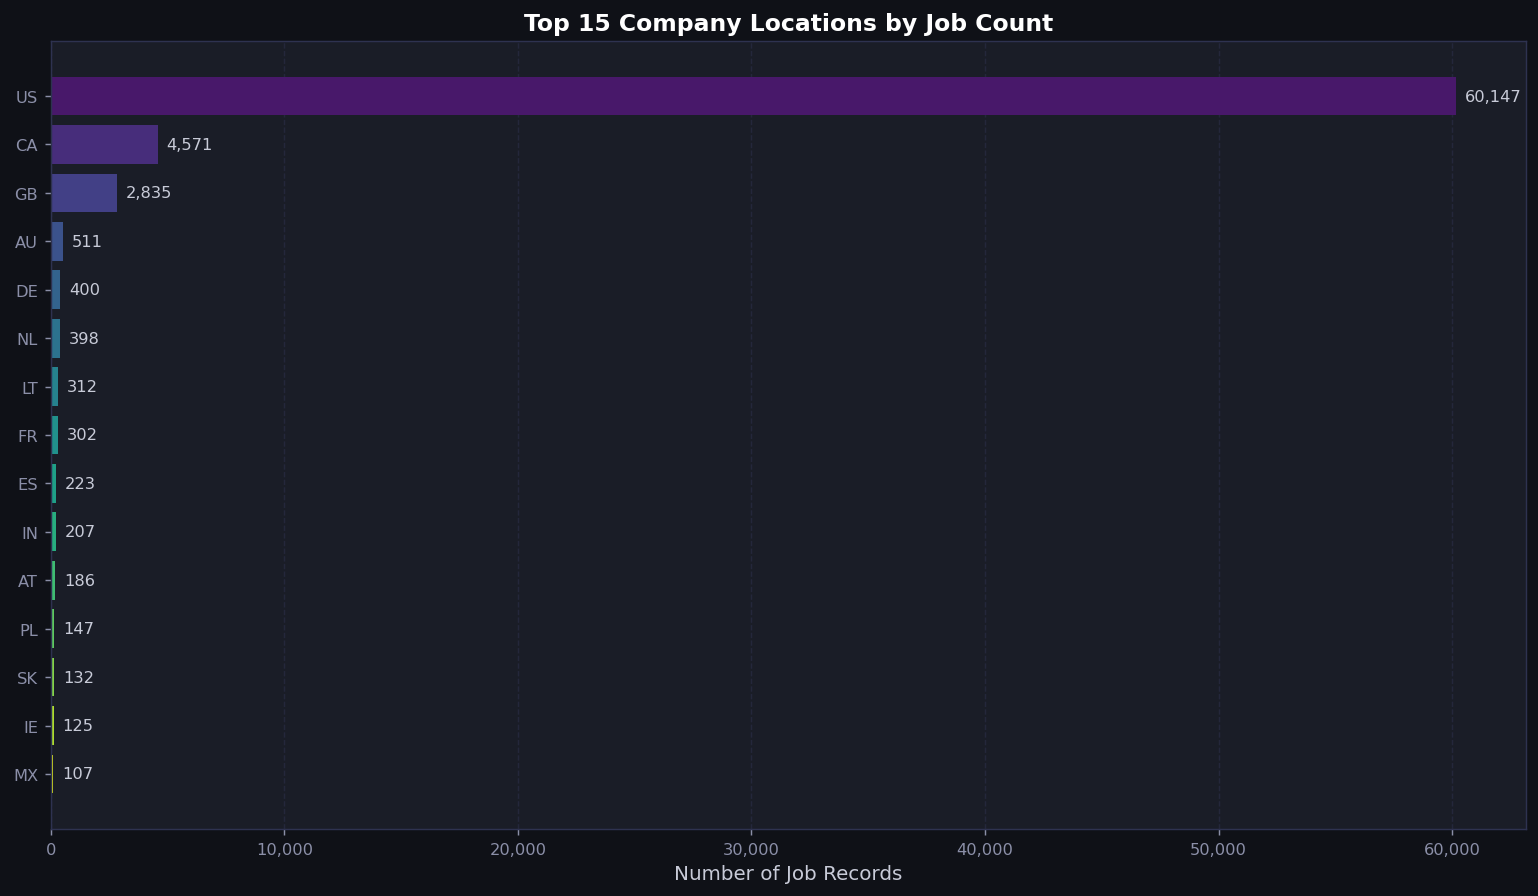

In [20]:
top_countries = df['company_location'].value_counts().head(15)

fig, ax = plt.subplots(figsize=(12, 7))
color_countries = sns.color_palette('viridis', n_colors=len(top_countries))
bars = ax.barh(top_countries.index[::-1], top_countries.values[::-1], color=color_countries[::-1], zorder=2)
ax.bar_label(bars, fmt='{:,.0f}', padding=5, color='#C8CBD8', fontsize=9)
ax.set_title('Top 15 Company Locations by Job Count', fontsize=13, fontweight='bold')
ax.set_xlabel('Number of Job Records')
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:,.0f}'))
ax.grid(axis='x', zorder=1)

save_fig('12_top_company_locations.png')
plt.show()

7.2 Median Salary by Country (Top 15 Countries by Volume)

Figure saved → figures\13_salary_by_country.png


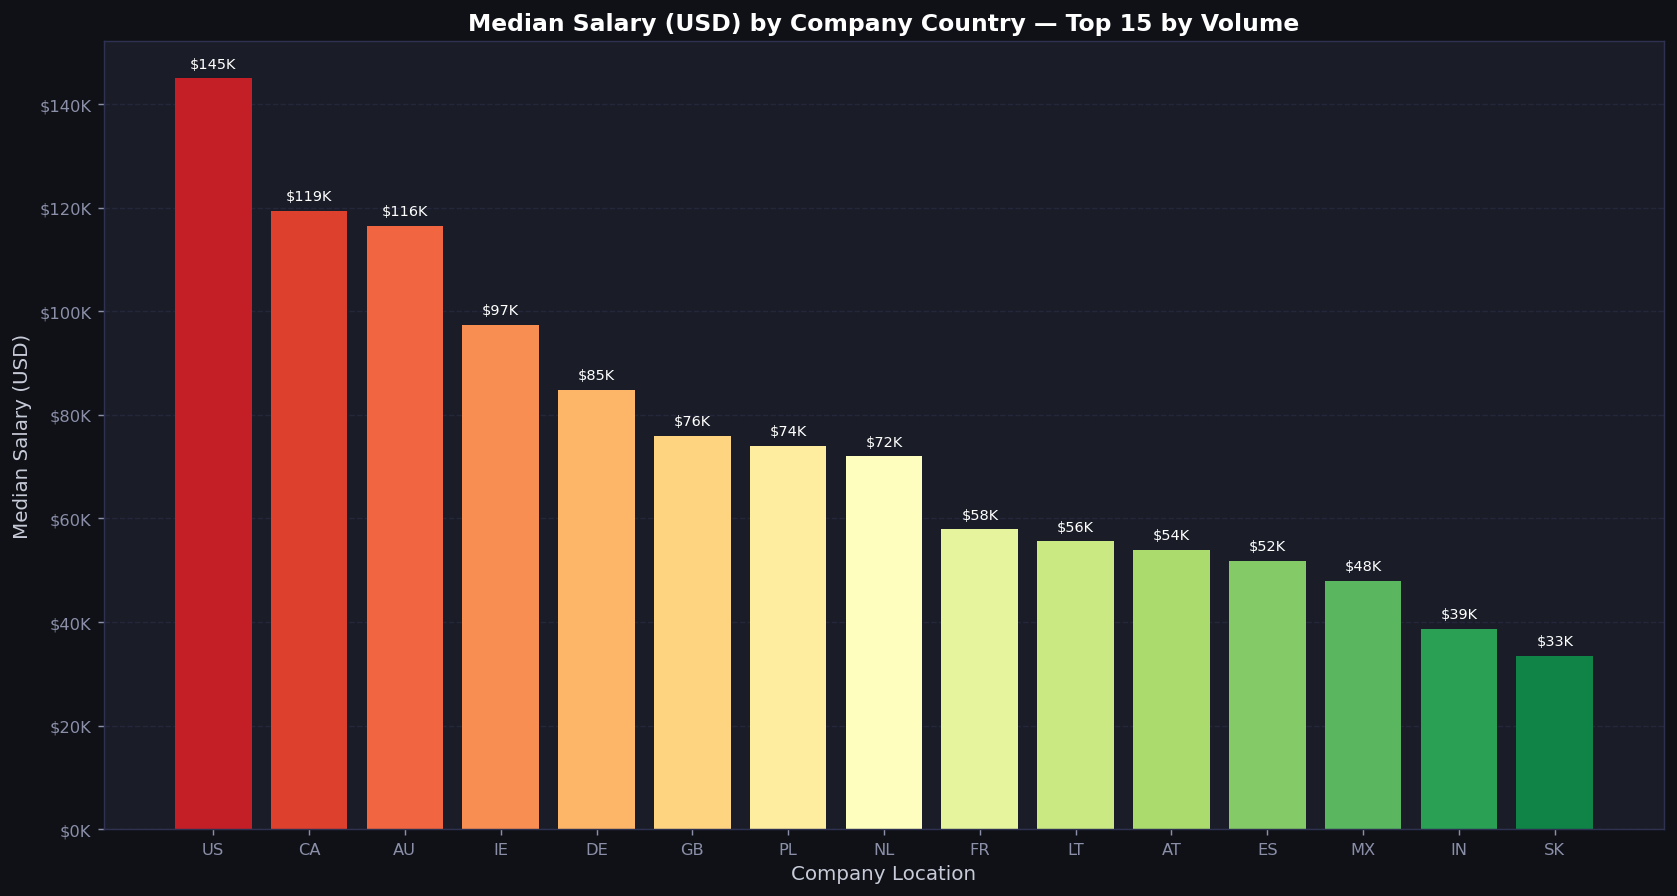

In [21]:
top15_countries = df['company_location'].value_counts().head(15).index
geo_salary = (
    df_clean[df_clean['company_location'].isin(top15_countries)]
    .groupby('company_location')['salary_in_usd']
    .agg(median='median', count='count')
    .sort_values('median', ascending=False)
    .reset_index()
)

fig, ax = plt.subplots(figsize=(13, 7))
colors_geo = sns.color_palette('RdYlGn', n_colors=len(geo_salary))
bars = ax.bar(geo_salary['company_location'], geo_salary['median'], color=colors_geo, zorder=2)

for bar, (_, row) in zip(bars, geo_salary.iterrows()):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1500,
            f'${row["median"]/1000:.0f}K', ha='center', va='bottom', fontsize=8, color='white')

ax.set_title('Median Salary (USD) by Company Country — Top 15 by Volume', fontsize=13, fontweight='bold')
ax.set_xlabel('Company Location')
ax.set_ylabel('Median Salary (USD)')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x/1000:.0f}K'))
ax.grid(axis='y', zorder=1)

save_fig('13_salary_by_country.png')
plt.show()

7.3 Remote Work Adoption by Country

Figure saved → figures\14_remote_ratio_by_country.png


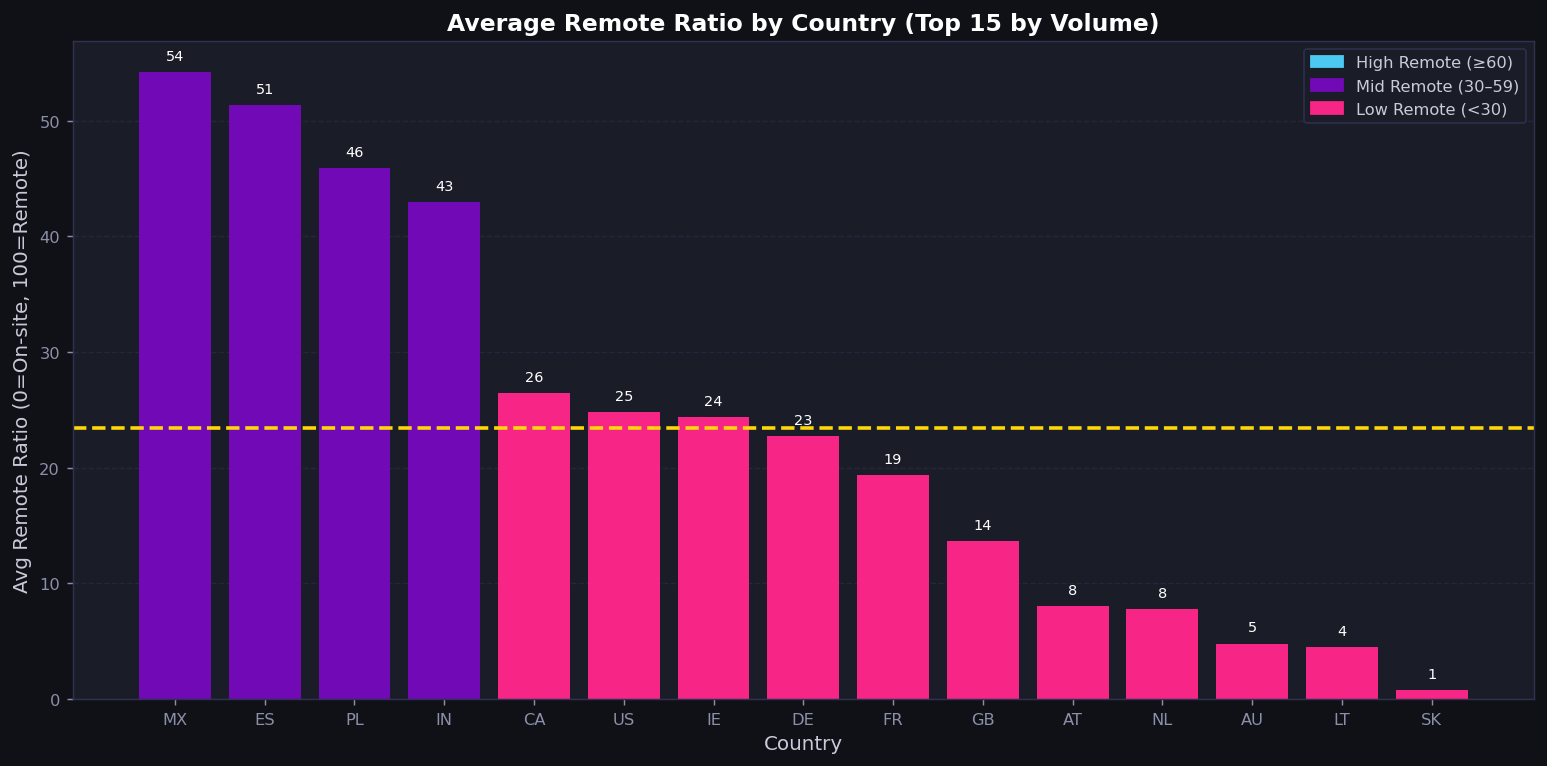

In [22]:
remote_by_country = (
    df[df['company_location'].isin(top15_countries)]
    .groupby('company_location')['remote_ratio']
    .mean()
    .sort_values(ascending=False)
    .reset_index()
)

fig, ax = plt.subplots(figsize=(12, 6))
bar_colors = ['#4CC9F0' if r >= 60 else ('#7209B7' if r >= 30 else '#F72585')
              for r in remote_by_country['remote_ratio']]
bars = ax.bar(remote_by_country['company_location'], remote_by_country['remote_ratio'],
              color=bar_colors, zorder=2)
ax.axhline(y=remote_by_country['remote_ratio'].mean(), color='#FFD60A', lw=2, ls='--',
           label=f'Average: {remote_by_country["remote_ratio"].mean():.1f}')

for bar, val in zip(bars, remote_by_country['remote_ratio']):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.8,
            f'{val:.0f}', ha='center', va='bottom', fontsize=8, color='white')

ax.set_title('Average Remote Ratio by Country (Top 15 by Volume)', fontsize=13, fontweight='bold')
ax.set_xlabel('Country')
ax.set_ylabel('Avg Remote Ratio (0=On-site, 100=Remote)')
ax.grid(axis='y', zorder=1)
ax.legend()

high_patch  = mpatches.Patch(color='#4CC9F0', label='High Remote (≥60)')
mid_patch   = mpatches.Patch(color='#7209B7', label='Mid Remote (30–59)')
low_patch   = mpatches.Patch(color='#F72585', label='Low Remote (<30)')
ax.legend(handles=[high_patch, mid_patch, low_patch], loc='upper right')

save_fig('14_remote_ratio_by_country.png')
plt.show()

8. Multivariate Analysis

8.1 Salary Heatmap: Experience Level × Role Family

Figure saved → figures\15_salary_heatmap_role_experience.png


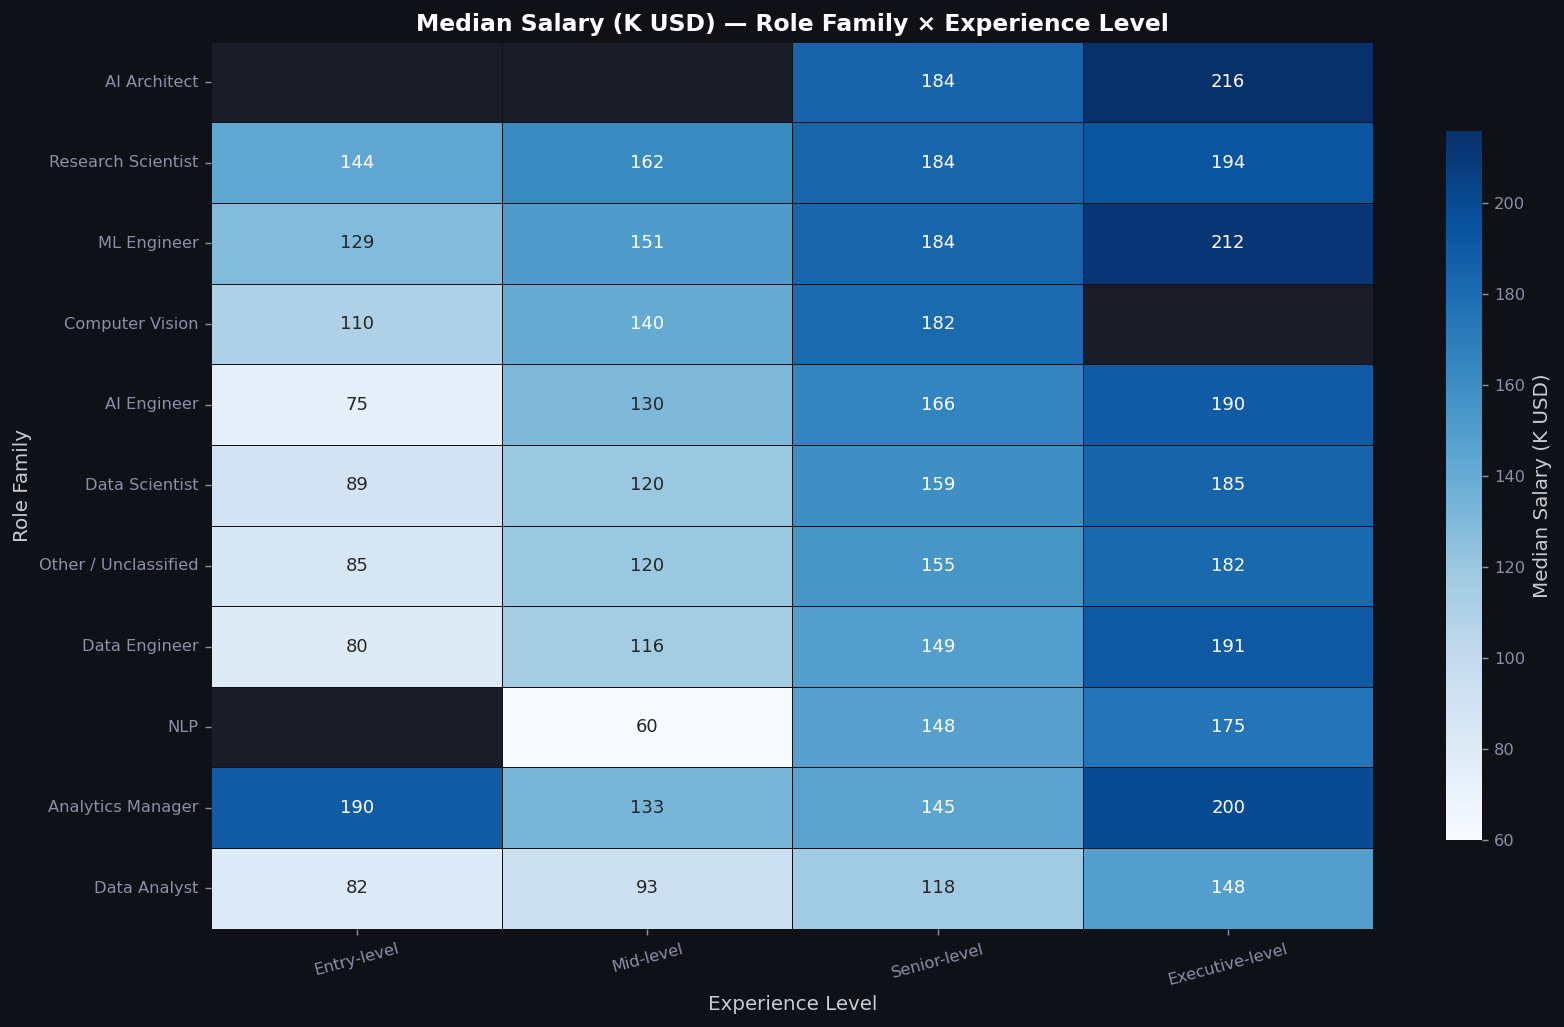

In [23]:
pivot_salary = (
    df_clean
    .pivot_table(index='role_family', columns='experience_level_label',
                 values='salary_in_usd', aggfunc='median')
    .reindex(columns=exp_order)
)
pivot_salary_sorted = pivot_salary.sort_values('Senior-level', ascending=False)

fig, ax = plt.subplots(figsize=(13, 8))
mask = pivot_salary_sorted.isnull()
sns.heatmap(
    pivot_salary_sorted / 1000,
    annot=True, fmt='.0f', cmap='Blues',
    linewidths=0.5, linecolor='#0F1117',
    mask=mask, ax=ax,
    cbar_kws={'label': 'Median Salary (K USD)', 'shrink': 0.8}
)
ax.set_title('Median Salary (K USD) — Role Family × Experience Level', fontsize=13, fontweight='bold')
ax.set_xlabel('Experience Level')
ax.set_ylabel('Role Family')
ax.tick_params(axis='x', rotation=15)
ax.tick_params(axis='y', rotation=0)

save_fig('15_salary_heatmap_role_experience.png')
plt.show()

8.2 Remote Ratio vs Salary by Experience Level

Figure saved → figures\16_remote_vs_salary_scatter.png


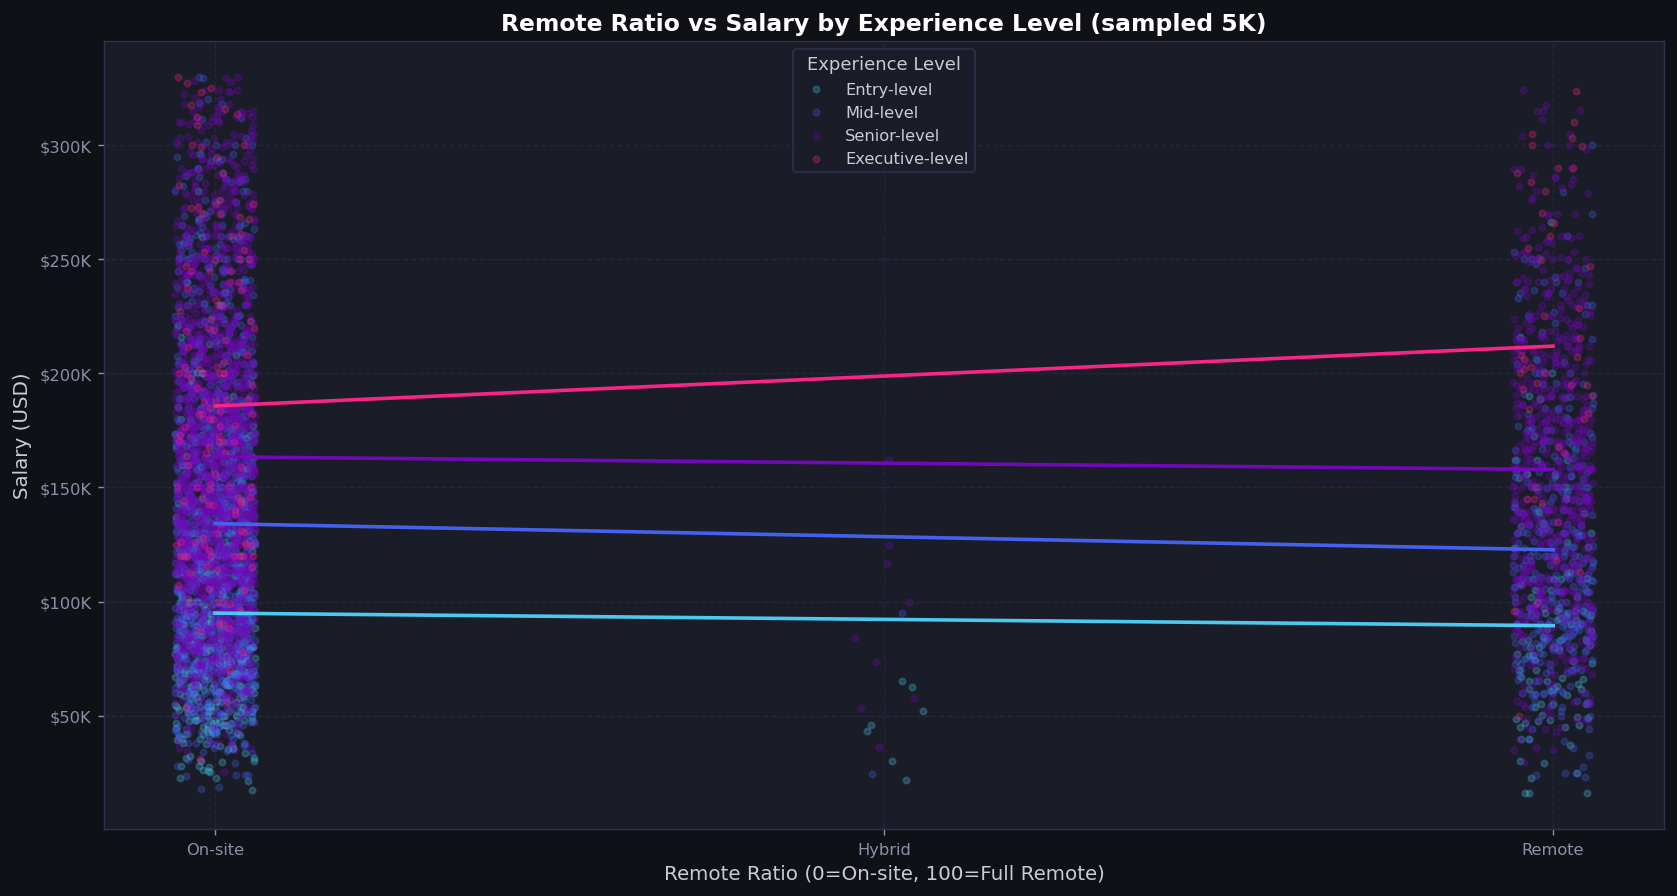

In [24]:
sample = df_clean.sample(min(5000, len(df_clean)), random_state=42)

fig, ax = plt.subplots(figsize=(13, 7))

for level, color in exp_palette.items():
    subset = sample[sample['experience_level_label'] == level]
    jitter = np.random.uniform(-3, 3, len(subset))
    ax.scatter(subset['remote_ratio'] + jitter, subset['salary_in_usd'],
               alpha=0.25, s=12, color=color, label=level)
    if len(subset) > 10:
        z = np.polyfit(subset['remote_ratio'], subset['salary_in_usd'], 1)
        p = np.poly1d(z)
        xs = np.linspace(0, 100, 100)
        ax.plot(xs, p(xs), color=color, lw=2)

ax.set_title('Remote Ratio vs Salary by Experience Level (sampled 5K)', fontsize=13, fontweight='bold')
ax.set_xlabel('Remote Ratio (0=On-site, 100=Full Remote)')
ax.set_ylabel('Salary (USD)')
ax.set_xticks([0, 50, 100])
ax.set_xticklabels(['On-site', 'Hybrid', 'Remote'])
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x/1000:.0f}K'))
ax.legend(title='Experience Level')
ax.grid()

save_fig('16_remote_vs_salary_scatter.png')
plt.show()

8.3 Salary Evolution by Experience Level Over Time

Figure saved → figures\17_salary_evolution_by_experience.png


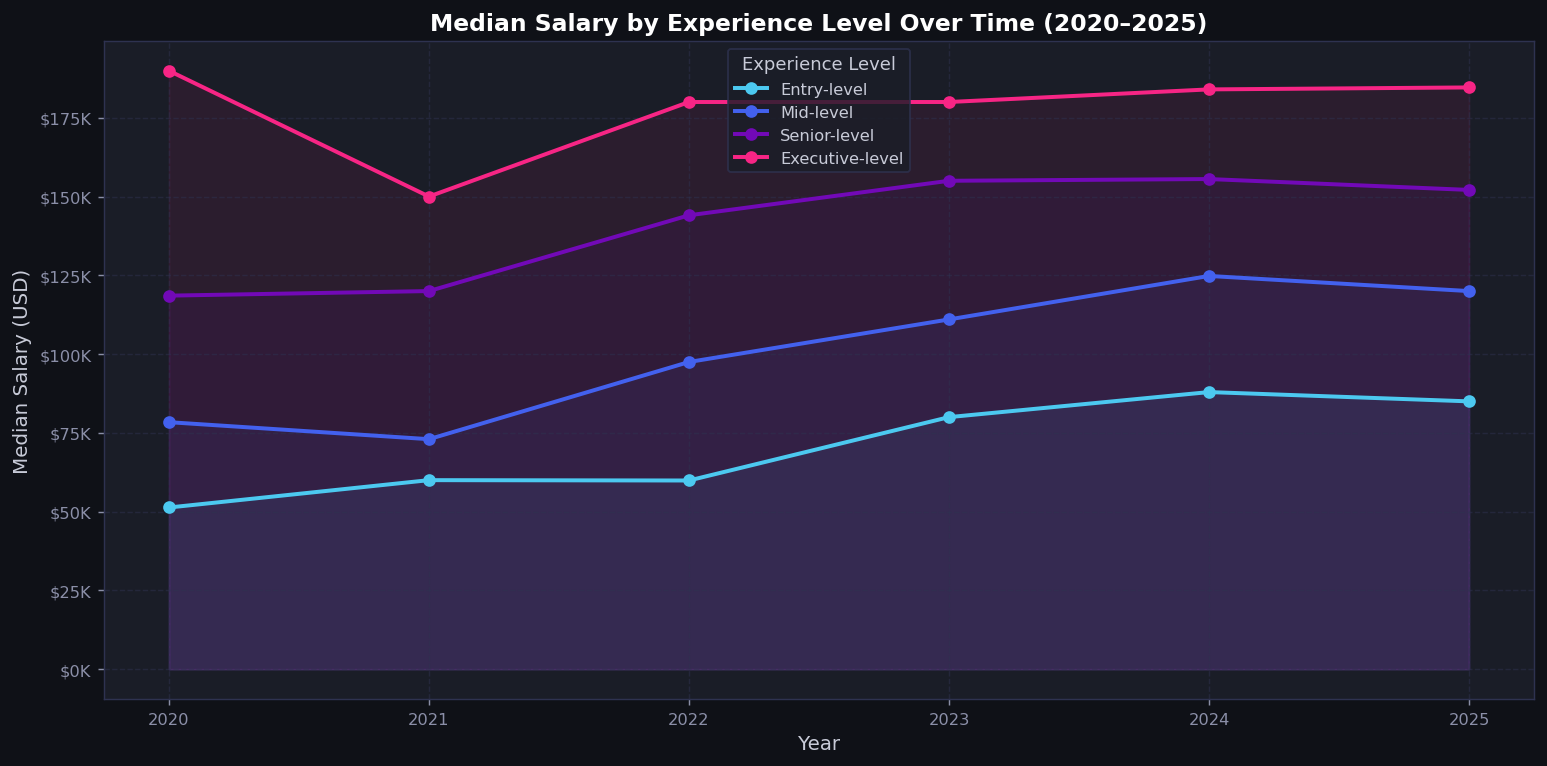

In [25]:
exp_time = (
    df_clean.groupby(['work_year', 'experience_level_label'])['salary_in_usd']
    .median()
    .reset_index()
)

fig, ax = plt.subplots(figsize=(12, 6))

for level, color in exp_palette.items():
    subset = exp_time[exp_time['experience_level_label'] == level]
    ax.plot(subset['work_year'], subset['salary_in_usd'], 'o-', color=color, lw=2.2, label=level)
    ax.fill_between(subset['work_year'], subset['salary_in_usd'], alpha=0.08, color=color)

ax.set_title('Median Salary by Experience Level Over Time (2020–2025)', fontsize=13, fontweight='bold')
ax.set_xlabel('Year')
ax.set_ylabel('Median Salary (USD)')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x/1000:.0f}K'))
ax.legend(title='Experience Level')
ax.grid()

save_fig('17_salary_evolution_by_experience.png')
plt.show()

8.4 Employment Type vs Salary by Company Size

Figure saved → figures\18_heatmap_employment_companysize.png


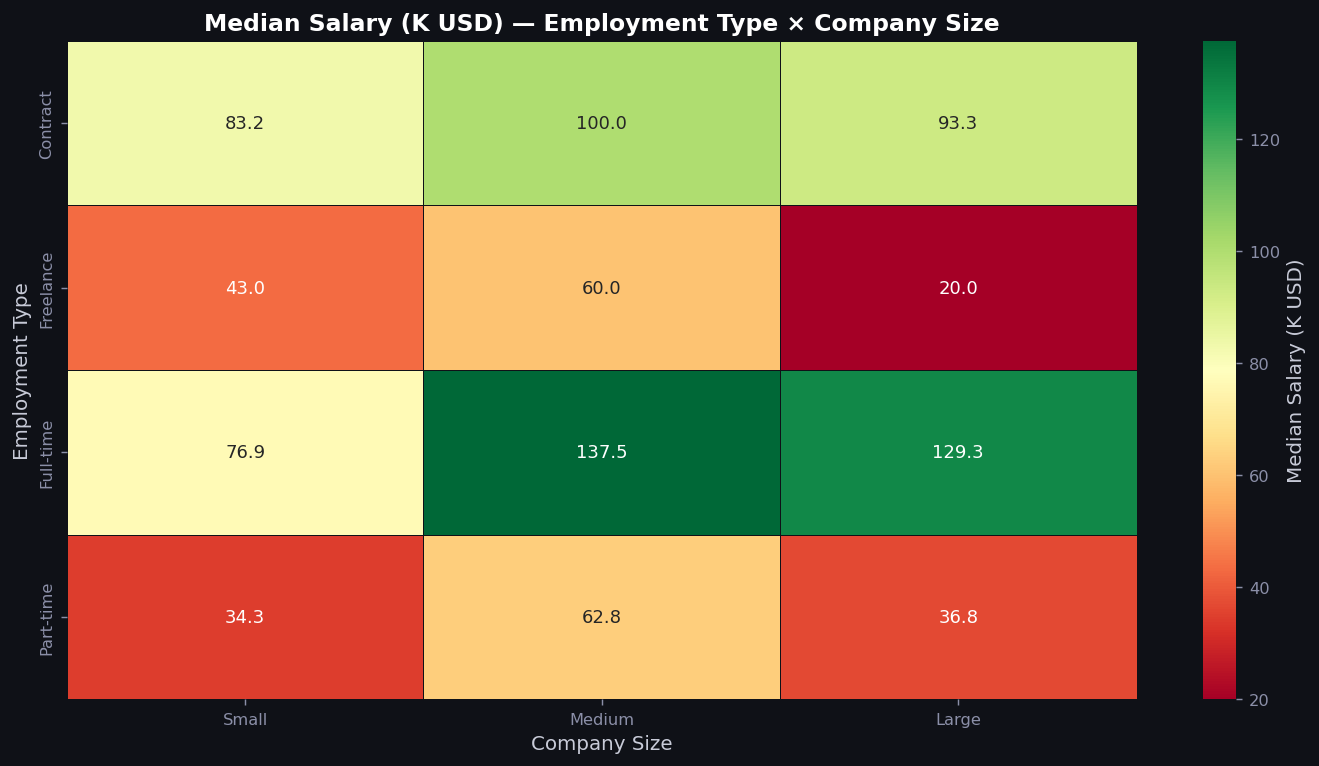

In [26]:
pivot_emp = (
    df_clean
    .pivot_table(index='employment_type_label', columns='company_size',
                 values='salary_in_usd', aggfunc='median')
    .reindex(columns=['S', 'M', 'L'])
)
pivot_emp.columns = ['Small', 'Medium', 'Large']

fig, ax = plt.subplots(figsize=(11, 6))
pivot_emp_k = pivot_emp / 1000
sns.heatmap(
    pivot_emp_k, annot=True, fmt='.1f', cmap='RdYlGn',
    linewidths=0.5, linecolor='#0F1117', ax=ax,
    cbar_kws={'label': 'Median Salary (K USD)'}
)
ax.set_title('Median Salary (K USD) — Employment Type × Company Size', fontsize=13, fontweight='bold')
ax.set_xlabel('Company Size')
ax.set_ylabel('Employment Type')
ax.tick_params(axis='x', rotation=0)

save_fig('18_heatmap_employment_companysize.png')
plt.show()

9. Outlier Analysis

9.1 Outlier Profile

In [27]:
print(f'Total Outliers: {len(df_outlier):,} ({len(df_outlier)/len(df)*100:.2f}%)')
print(f'Outlier Salary Range: ${df_outlier["salary_in_usd"].min():,.0f} – ${df_outlier["salary_in_usd"].max():,.0f}')
print()
print('Outlier by Experience Level:')
print(df_outlier['experience_level_label'].value_counts())
print()
print('Top Outlier Job Titles:')
print(df_outlier['job_title'].value_counts().head(10))

Total Outliers: 1,754 (2.44%)
Outlier Salary Range: $332,000 – $800,000

Outlier by Experience Level:
experience_level_label
Senior-level       1079
Mid-level           424
Executive-level     203
Entry-level          48
Name: count, dtype: int64

Top Outlier Job Titles:
job_title
Software Engineer            217
Engineer                     186
Machine Learning Engineer    179
Manager                      118
Data Scientist               112
Research Scientist           104
Research Engineer             88
Data Engineer                 75
Engineering Manager           74
Product Manager               42
Name: count, dtype: int64


Figure saved → figures\19_outlier_analysis.png


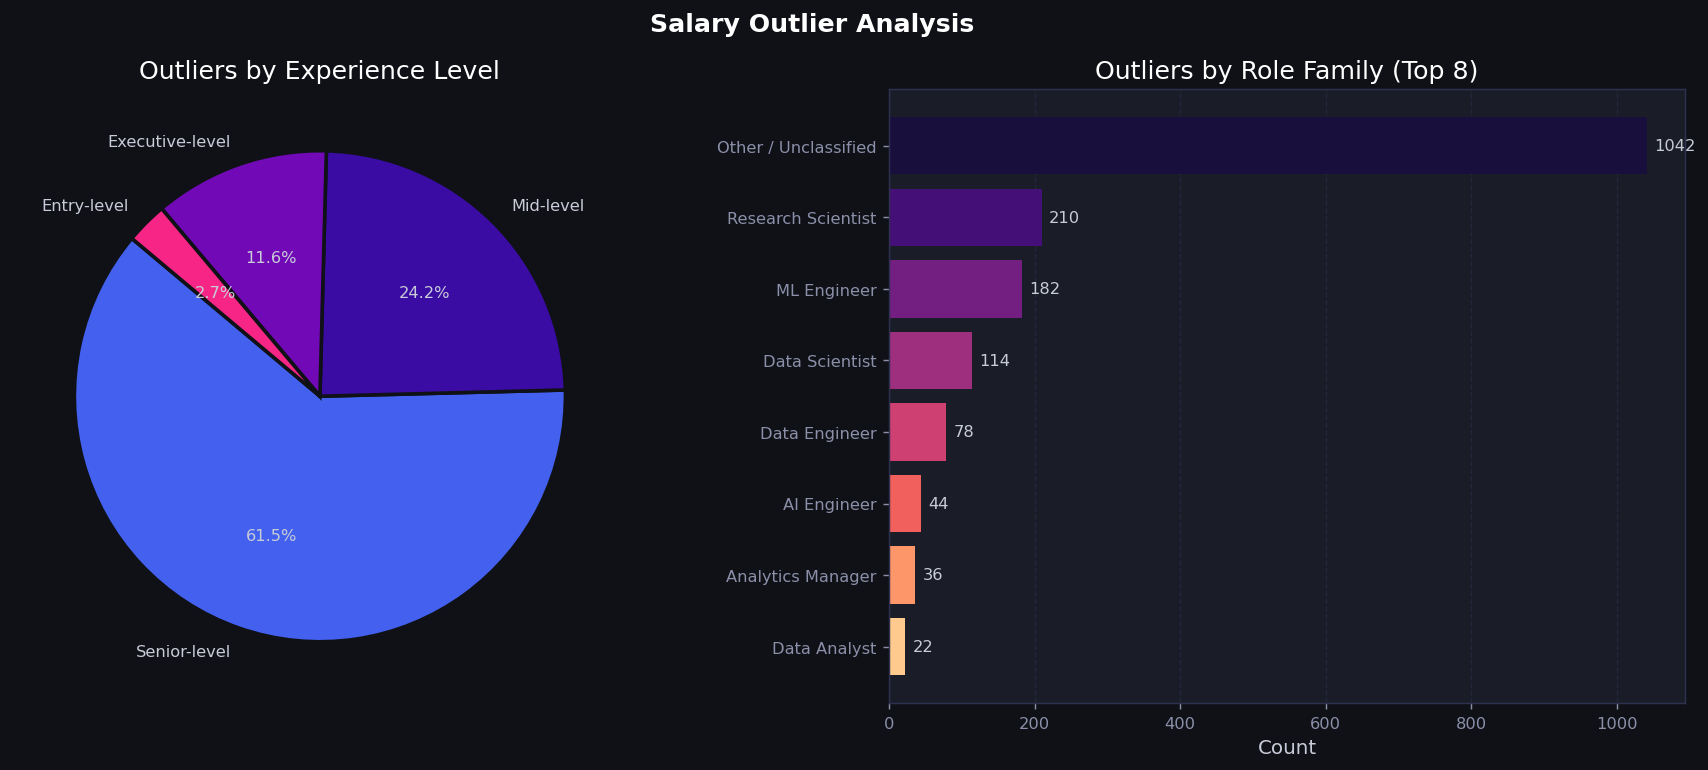

In [28]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle('Salary Outlier Analysis', fontsize=14, fontweight='bold', color='white')

outlier_exp = df_outlier['experience_level_label'].value_counts()
axes[0].pie(outlier_exp.values, labels=outlier_exp.index,
            colors=PALETTE_PRIMARY, autopct='%1.1f%%', startangle=140,
            wedgeprops={'edgecolor': '#0F1117', 'linewidth': 2},
            textprops={'color': '#C8CBD8', 'fontsize': 9})
axes[0].set_title('Outliers by Experience Level')

outlier_role = df_outlier['role_family'].value_counts().head(8)
colors_role = sns.color_palette('magma', n_colors=len(outlier_role))
bars2 = axes[1].barh(outlier_role.index[::-1], outlier_role.values[::-1], color=colors_role[::-1], zorder=2)
axes[1].bar_label(bars2, padding=4, color='#C8CBD8', fontsize=9)
axes[1].set_title('Outliers by Role Family (Top 8)')
axes[1].set_xlabel('Count')
axes[1].grid(axis='x', zorder=1)

save_fig('19_outlier_analysis.png')
plt.show()

9.2 IQR-Based Outlier Detection on Cleaned Data

IQR Q1: $95,000  |  Q3: $185,800  |  IQR: $90,800
Fences: [-41,200, 322,000]
IQR Outliers in cleaned set: 287 (0.41%)
Figure saved → figures\20_iqr_outlier_boundaries.png


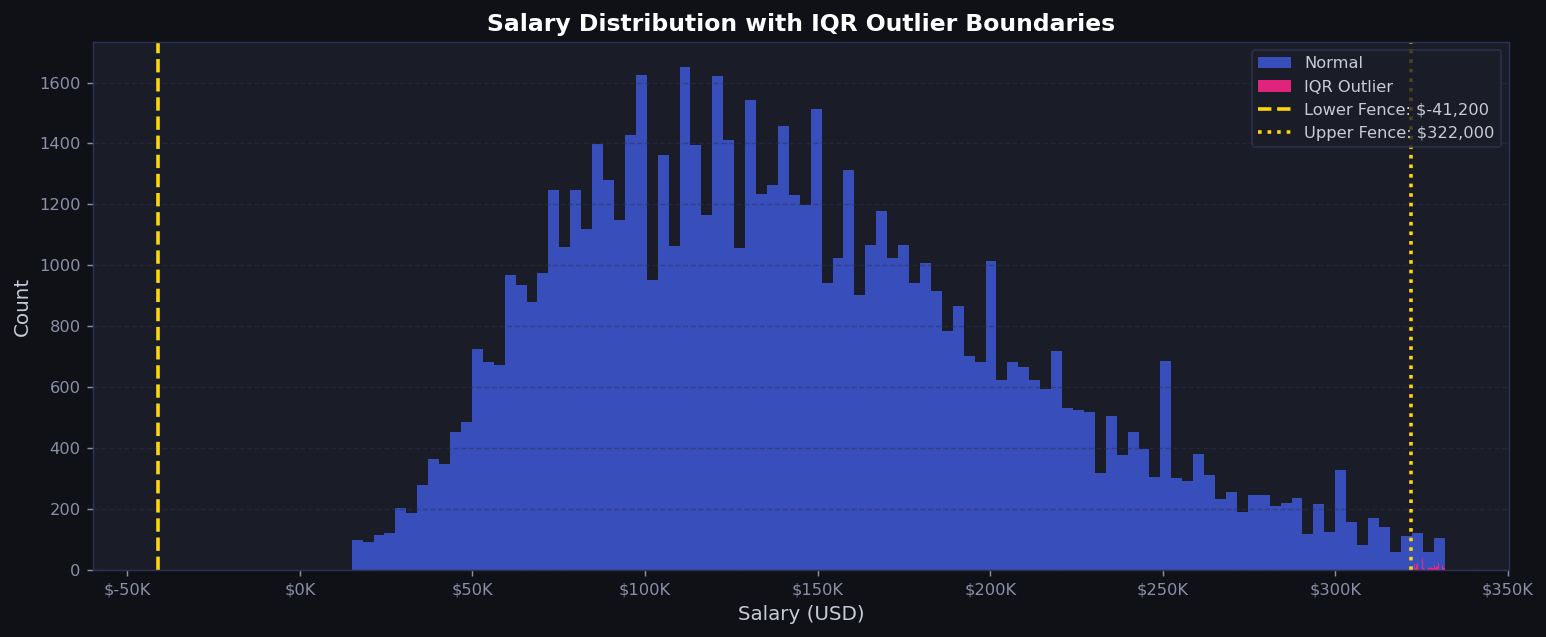

In [29]:
Q1  = df_clean['salary_in_usd'].quantile(0.25)
Q3  = df_clean['salary_in_usd'].quantile(0.75)
IQR = Q3 - Q1
lower_fence = Q1 - 1.5 * IQR
upper_fence = Q3 + 1.5 * IQR

iqr_outliers = df_clean[(df_clean['salary_in_usd'] < lower_fence) | (df_clean['salary_in_usd'] > upper_fence)]

print(f'IQR Q1: ${Q1:,.0f}  |  Q3: ${Q3:,.0f}  |  IQR: ${IQR:,.0f}')
print(f'Fences: [{lower_fence:,.0f}, {upper_fence:,.0f}]')
print(f'IQR Outliers in cleaned set: {len(iqr_outliers):,} ({len(iqr_outliers)/len(df_clean)*100:.2f}%)')

fig, ax = plt.subplots(figsize=(12, 5))
ax.hist(df_clean['salary_in_usd'], bins=100, color='#4361EE', alpha=0.75, label='Normal')
ax.hist(iqr_outliers['salary_in_usd'], bins=30, color='#F72585', alpha=0.9, label='IQR Outlier')
ax.axvline(lower_fence, color='#FFD60A', lw=2, ls='--', label=f'Lower Fence: ${lower_fence:,.0f}')
ax.axvline(upper_fence, color='#FFD60A', lw=2, ls=':',  label=f'Upper Fence: ${upper_fence:,.0f}')
ax.set_title('Salary Distribution with IQR Outlier Boundaries', fontsize=13, fontweight='bold')
ax.set_xlabel('Salary (USD)')
ax.set_ylabel('Count')
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x/1000:.0f}K'))
ax.legend()
ax.grid(axis='y')

save_fig('20_iqr_outlier_boundaries.png')
plt.show()

10. Role Family Deep Dive

10.1 Role Family Market Share Over Time

Figure saved → figures\21_role_family_market_share.png


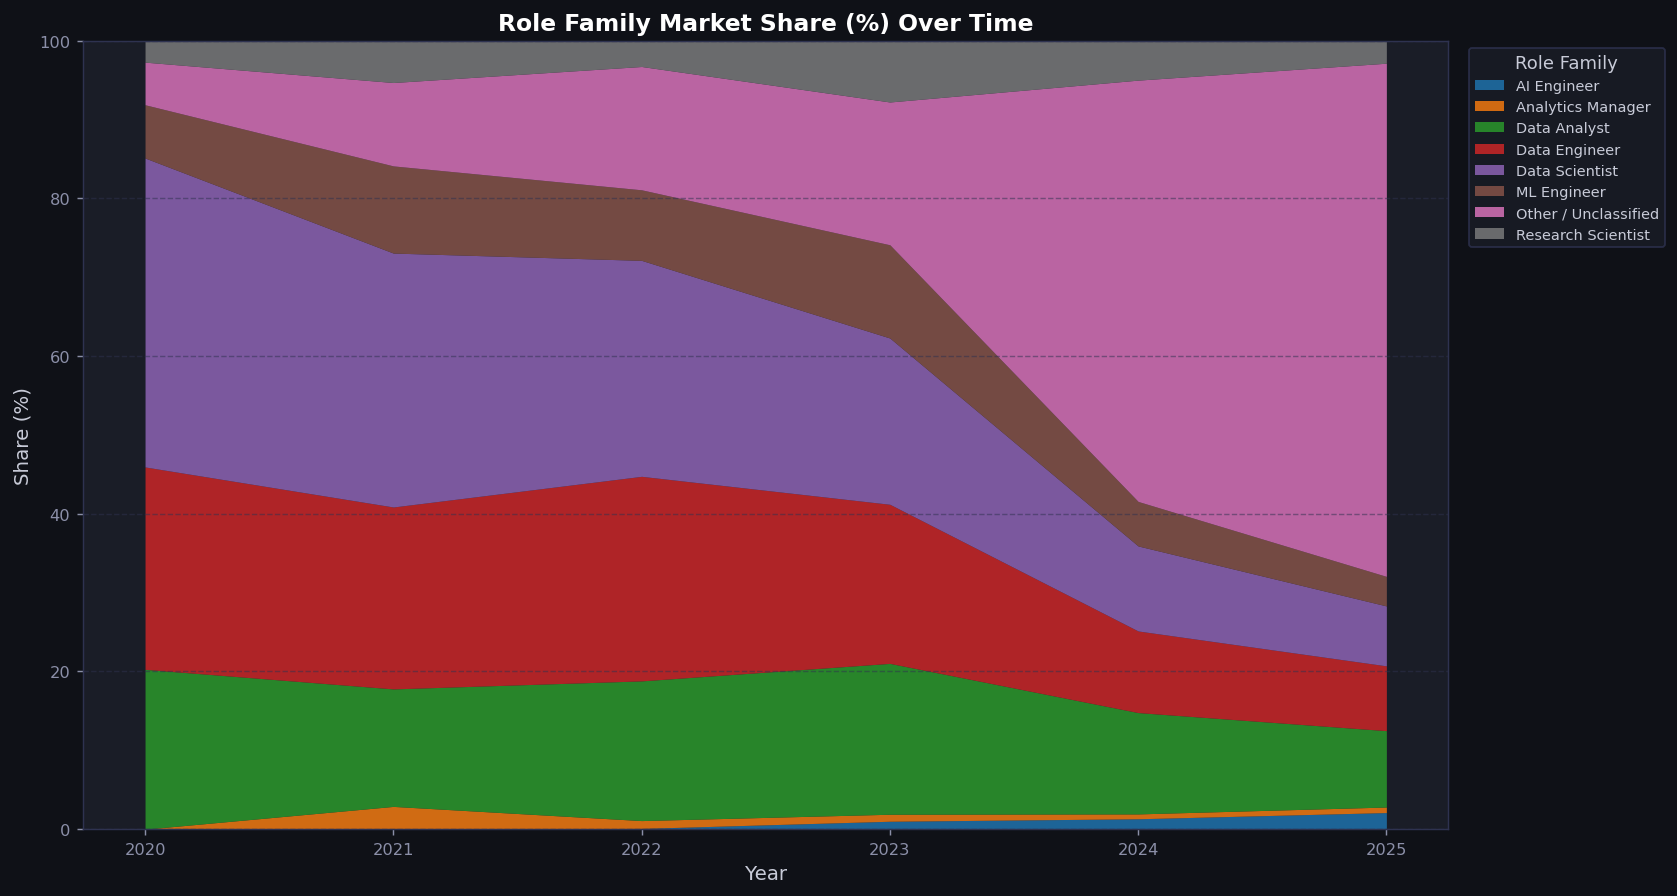

In [30]:
role_share = (
    df[df['role_family'].isin(top_roles)]
    .groupby(['work_year', 'role_family'])
    .size()
    .unstack(fill_value=0)
)
role_share_pct = role_share.div(role_share.sum(axis=1), axis=0) * 100

fig, ax = plt.subplots(figsize=(13, 7))
pal_area = sns.color_palette('tab10', n_colors=len(role_share_pct.columns))

role_share_pct.plot.area(ax=ax, color=pal_area, alpha=0.8, linewidth=0)
ax.set_title('Role Family Market Share (%) Over Time', fontsize=13, fontweight='bold')
ax.set_xlabel('Year')
ax.set_ylabel('Share (%)')
ax.set_ylim(0, 100)
ax.legend(title='Role Family', bbox_to_anchor=(1.01, 1), loc='upper left', fontsize=8)
ax.grid(axis='y')

save_fig('21_role_family_market_share.png')
plt.show()

10.2 Salary Comparison: Emerging AI Roles vs Traditional Roles

Figure saved → figures\22_ai_vs_traditional_salary.png


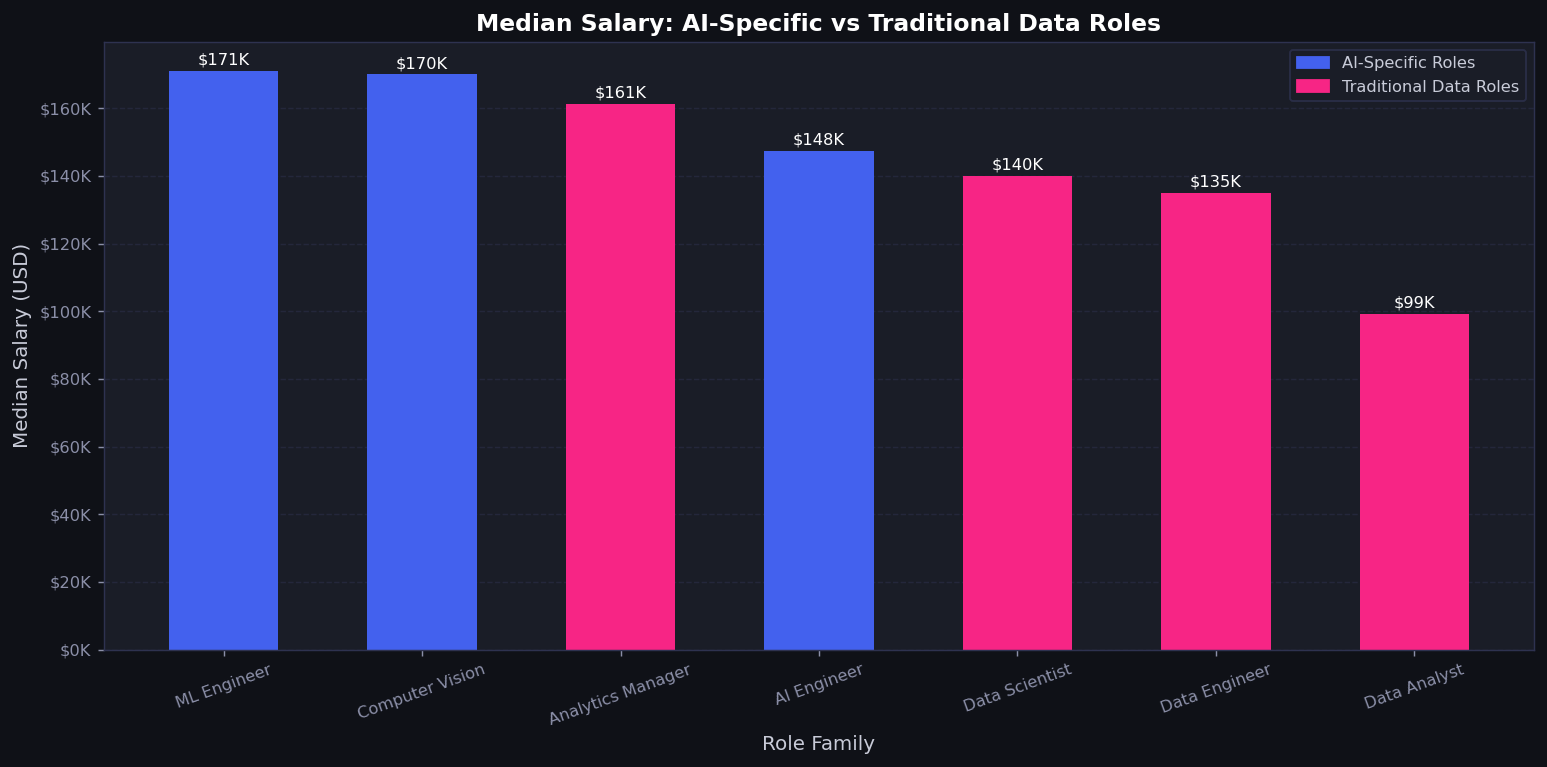

In [31]:
ai_roles          = ['AI Engineer', 'ML Engineer', 'Computer Vision', 'NLP / GenAI']
traditional_roles = ['Data Analyst', 'Data Engineer', 'Data Scientist', 'Analytics Manager']

def get_role_stats(roles, label, color):
    sub = df_clean[df_clean['role_family'].isin(roles)].copy()
    agg = sub.groupby('role_family')['salary_in_usd'].agg(median='median', count='count').reset_index()
    agg['category'] = label
    agg['color']    = color
    return agg[agg['role_family'].isin(roles)]

ai_stats   = get_role_stats(ai_roles,          'AI-Specific', '#4361EE')
trad_stats = get_role_stats(traditional_roles, 'Traditional',  '#F72585')
combined   = pd.concat([ai_stats, trad_stats]).sort_values('median', ascending=False)

fig, ax = plt.subplots(figsize=(12, 6))
color_map = {r: '#4361EE' for r in ai_roles}
color_map.update({r: '#F72585' for r in traditional_roles})
bar_colors = [color_map.get(r, '#888') for r in combined['role_family']]

bars = ax.bar(combined['role_family'], combined['median'], color=bar_colors, width=0.55, zorder=2)
for bar, (_, row) in zip(bars, combined.iterrows()):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1000,
            f'${row["median"]/1000:.0f}K', ha='center', va='bottom', fontsize=9, color='white')

ax.set_title('Median Salary: AI-Specific vs Traditional Data Roles', fontsize=13, fontweight='bold')
ax.set_xlabel('Role Family')
ax.set_ylabel('Median Salary (USD)')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x/1000:.0f}K'))
ax.tick_params(axis='x', rotation=20)
ax.grid(axis='y', zorder=1)

ai_patch   = mpatches.Patch(color='#4361EE', label='AI-Specific Roles')
trad_patch = mpatches.Patch(color='#F72585', label='Traditional Data Roles')
ax.legend(handles=[ai_patch, trad_patch])

save_fig('22_ai_vs_traditional_salary.png')
plt.show()

11. Correlation & Statistical Analysis

11.1 Numerical Feature Correlation

Figure saved → figures\23_correlation_matrix.png


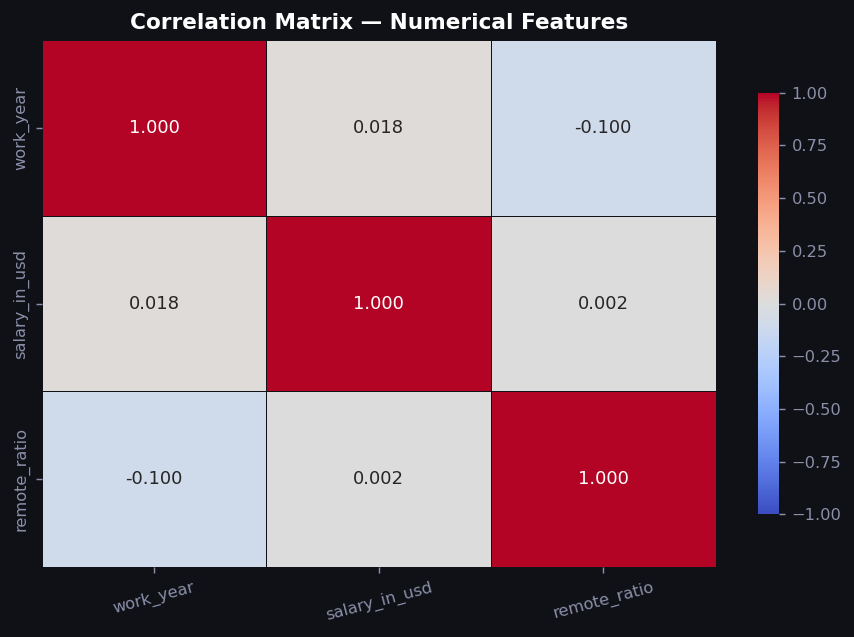

               work_year  salary_in_usd  remote_ratio
work_year       1.000000       0.017580     -0.099797
salary_in_usd   0.017580       1.000000      0.001513
remote_ratio   -0.099797       0.001513      1.000000


In [32]:
num_cols = ['work_year', 'salary_in_usd', 'remote_ratio']
corr_matrix = df_clean[num_cols].corr()

fig, ax = plt.subplots(figsize=(7, 5))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(
    corr_matrix, annot=True, fmt='.3f', cmap='coolwarm',
    vmin=-1, vmax=1, center=0,
    linewidths=0.5, linecolor='#0F1117',
    ax=ax, cbar_kws={'shrink': 0.8}
)
ax.set_title('Correlation Matrix — Numerical Features', fontsize=12, fontweight='bold')
ax.tick_params(axis='x', rotation=15)

save_fig('23_correlation_matrix.png')
plt.show()
print(corr_matrix)

11.2 ANOVA — Salary Difference Across Experience Levels

In [33]:
groups = [df_clean[df_clean['experience_level_label'] == lvl]['salary_in_usd'].values
          for lvl in exp_order]

f_stat, p_value = stats.f_oneway(*groups)

print('=== One-Way ANOVA: Salary ~ Experience Level ===')
print(f'F-statistic : {f_stat:,.2f}')
print(f'p-value     : {p_value:.4e}')
print()
if p_value < 0.05:
    print('Result: Statistically significant difference in salary across experience levels (p < 0.05).')
else:
    print('Result: No statistically significant difference detected (p ≥ 0.05).')

=== One-Way ANOVA: Salary ~ Experience Level ===
F-statistic : 3,430.76
p-value     : 0.0000e+00

Result: Statistically significant difference in salary across experience levels (p < 0.05).


11.3 Salary Growth Rate YoY

Figure saved → figures\24_yoy_salary_growth.png


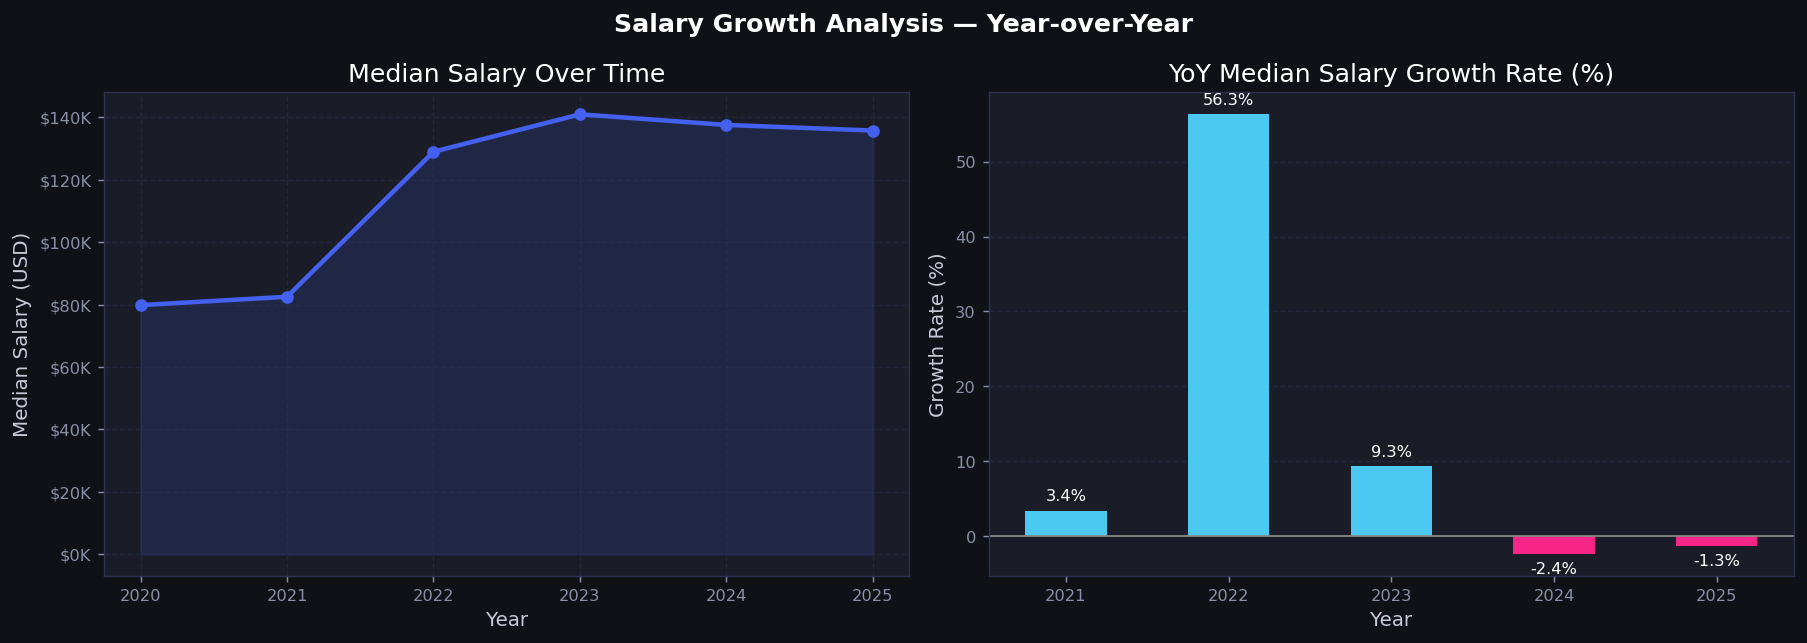

 year   median  yoy_growth_pct
 2020  79833.0             NaN
 2021  82514.0        3.358260
 2022 129000.0       56.337106
 2023 141000.0        9.302326
 2024 137600.0       -2.411348
 2025 135800.0       -1.308140


In [34]:
yoy = salary_trend[['year', 'median']].copy()
yoy['yoy_growth_pct'] = yoy['median'].pct_change() * 100

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Salary Growth Analysis — Year-over-Year', fontsize=14, fontweight='bold', color='white')

axes[0].plot(yoy['year'], yoy['median'], 'o-', color='#4361EE', lw=2.5)
axes[0].fill_between(yoy['year'], yoy['median'], alpha=0.15, color='#4361EE')
axes[0].set_title('Median Salary Over Time')
axes[0].set_xlabel('Year')
axes[0].set_ylabel('Median Salary (USD)')
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x/1000:.0f}K'))
axes[0].grid()

yoy_plot = yoy.dropna(subset=['yoy_growth_pct'])
bar_colors_yoy = ['#4CC9F0' if v >= 0 else '#F72585' for v in yoy_plot['yoy_growth_pct']]
bars = axes[1].bar(yoy_plot['year'], yoy_plot['yoy_growth_pct'], color=bar_colors_yoy, width=0.5, zorder=2)
axes[1].bar_label(bars, fmt='%.1f%%', padding=4, color='white', fontsize=9)
axes[1].axhline(0, color='#888', lw=1)
axes[1].set_title('YoY Median Salary Growth Rate (%)')
axes[1].set_xlabel('Year')
axes[1].set_ylabel('Growth Rate (%)')
axes[1].grid(axis='y', zorder=1)

save_fig('24_yoy_salary_growth.png')
plt.show()

print(yoy.to_string(index=False))

12. Summary Dashboard

Figure saved → figures\00_summary_dashboard.png


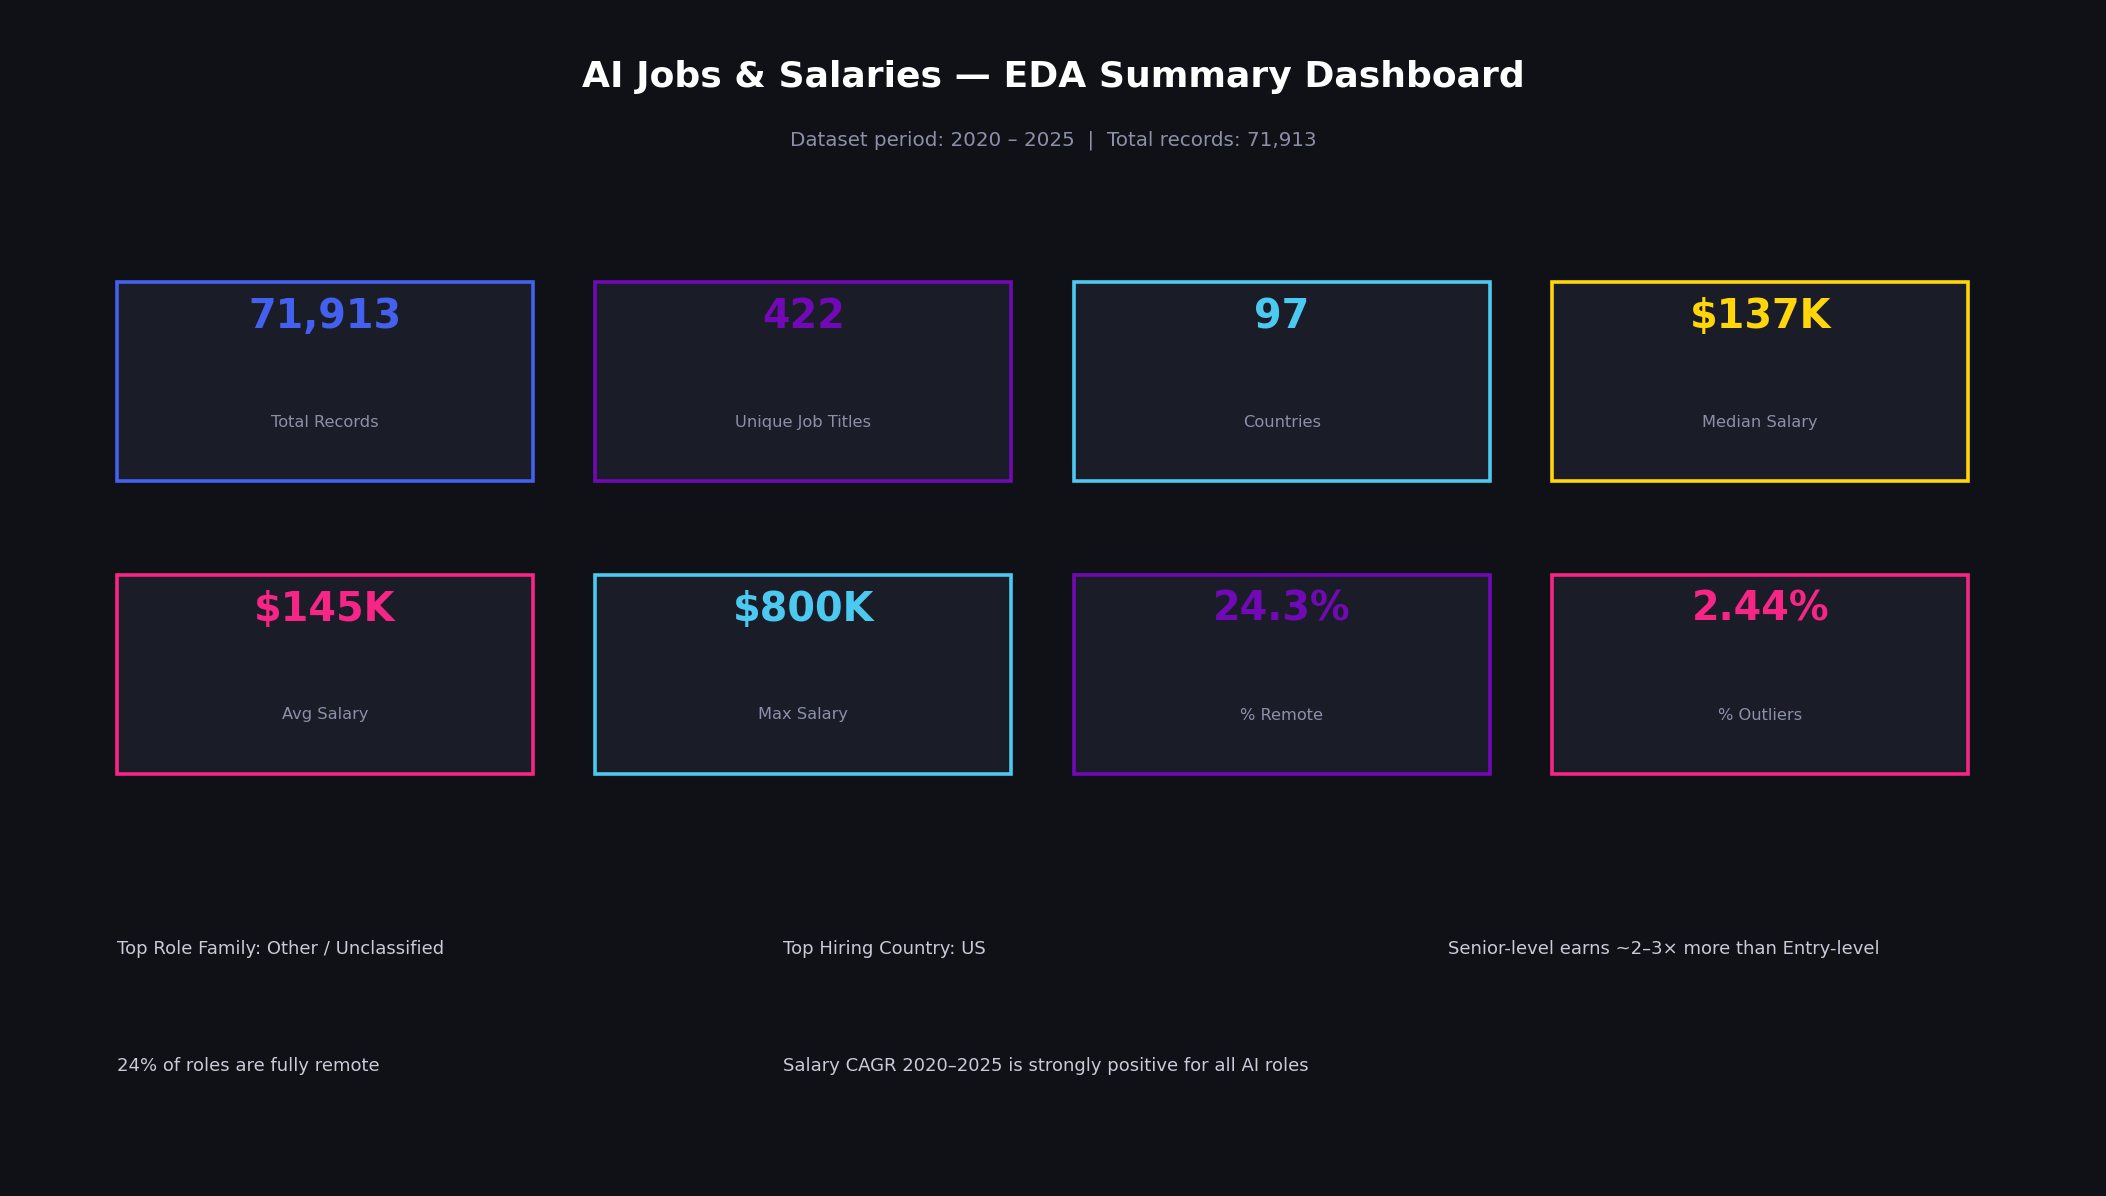

In [35]:
total_records   = len(df)
unique_titles   = df['job_title'].nunique()
unique_countries= df['company_location'].nunique()
median_salary   = df_clean['salary_in_usd'].median()
mean_salary     = df_clean['salary_in_usd'].mean()
max_salary      = df['salary_in_usd'].max()
top_role        = df['role_family'].value_counts().idxmax()
top_country     = df['company_location'].value_counts().idxmax()
pct_remote      = (df['work_mode'] == 'Remote').mean() * 100
pct_outlier     = df['salary_outlier_flag'].mean() * 100
year_range      = f"{df['work_year'].min()} – {df['work_year'].max()}"

fig = plt.figure(figsize=(16, 9))
fig.patch.set_facecolor('#0F1117')
ax = fig.add_axes([0, 0, 1, 1])
ax.axis('off')

ax.text(0.5, 0.96, 'AI Jobs & Salaries — EDA Summary Dashboard',
        ha='center', va='top', fontsize=20, fontweight='bold', color='white', transform=ax.transAxes)
ax.text(0.5, 0.90, f'Dataset period: {year_range}  |  Total records: {total_records:,}',
        ha='center', va='top', fontsize=11, color='#8B8FA8', transform=ax.transAxes)

kpis = [
    ('Total Records',     f'{total_records:,}',        '#4361EE'),
    ('Unique Job Titles', f'{unique_titles:,}',         '#7209B7'),
    ('Countries',         f'{unique_countries}',        '#4CC9F0'),
    ('Median Salary',     f'${median_salary/1000:.0f}K','#FFD60A'),
    ('Avg Salary',        f'${mean_salary/1000:.0f}K',  '#F72585'),
    ('Max Salary',        f'${max_salary/1000:.0f}K',   '#4CC9F0'),
    ('% Remote',          f'{pct_remote:.1f}%',         '#7209B7'),
    ('% Outliers',        f'{pct_outlier:.2f}%',        '#F72585'),
]

n_kpi = len(kpis)
for i, (title, value, color) in enumerate(kpis):
    x = 0.05 + (i % 4) * 0.23
    y = 0.72 if i < 4 else 0.47
    rect = plt.Rectangle((x, y - 0.12), 0.2, 0.17, transform=ax.transAxes,
                           facecolor='#1A1D27', edgecolor=color, linewidth=2, zorder=2)
    ax.add_patch(rect)
    ax.text(x + 0.10, y + 0.02, value, ha='center', va='center',
            fontsize=22, fontweight='bold', color=color, transform=ax.transAxes)
    ax.text(x + 0.10, y - 0.07, title, ha='center', va='center',
            fontsize=9, color='#8B8FA8', transform=ax.transAxes)

insights = [
    f'Top Role Family: {top_role}',
    f'Top Hiring Country: {top_country}',
    f'Senior-level earns ~2–3× more than Entry-level',
    f'{pct_remote:.0f}% of roles are fully remote',
    f'Salary CAGR 2020–2025 is strongly positive for all AI roles',
]
for j, txt in enumerate(insights):
    ax.text(0.05 + (j % 3) * 0.32, 0.20 - (j // 3) * 0.10, txt,
            ha='left', va='center', fontsize=10, color='#C8CBD8', transform=ax.transAxes)

save_fig('00_summary_dashboard.png', tight=False)
plt.show()